# Clasificación de sentimiento en reseñas de productos — Parte 1 (ML clásico)
## Modelo v3b: ensemble v1 + componente estructural + polaridad por fragmento

**Curso Aprendizaje de Máquina 2026-20 · Universidad de los Andes**

**Integrantes:** _(completar)_

## Objetivo
Predecir el sentimiento global (`negativo`, `neutral`, `positivo`) de reseñas en español usando **solo** representaciones clásicas de texto (bolsa de palabras, TF-IDF, n-gramas), ingeniería de rasgos con reglas, expresiones regulares y léxicos, y clasificadores de **scikit-learn**. No usamos redes neuronales, transformers ni embeddings preentrenados.

## Resumen de resultados
Accuracy en validación cruzada estratificada de 5 folds sobre `train.csv`. Todas las predicciones *out-of-fold* (OOF) usan la misma partición (`random_state=42`), así que las comparaciones son pareadas. La columna "selección anidada" estima la accuracy del ensemble descontando el sobreajuste de elegir los pesos con esas mismas OOF.

| Iteración | Modelo | Accuracy OOF | Selección anidada | Kaggle público |
|---|---|---|---|---|
| 0 | Línea base: TF-IDF de palabras sobre el texto completo + regresión logística | 0.7408 | | |
| 1–4 | Bloques de texto según los conectores + LR / SVM / stacking | 0.895 – 0.901 | | |
| 5 | **Ensemble v1** (voto suave de 4 modelos) → `submission.csv` | 0.9069 | 0.9067 | **0.90111** |
| 6 | Componente nuevo **estructural** (parser de plantillas + HistGradientBoosting) | 0.9075 | | |
| 7 | Componente nuevo **est_lr** (polaridad por fragmento + regresión logística) | 0.9126 | | |
| 8 | **Ensemble v3b** = v1 + estructural + est_lr → `submission_v3b.csv` | **0.9180** | **0.9169** | _(por enviar)_ |

Con una segunda partición (`random_state=2024`) la selección anidada pasa de 0.9043 (v1) a 0.9145 (v3b): +1.02 pts, igual que con la partición 42. Repitiendo la selección anidada con 3 semillas en las 2 particiones (sección 13.1), la mejora de v3b sobre v1 es de **+1.03 pts de media** (entre +0.89 y +1.18), con McNemar anidado significativo en las 6 combinaciones. Como el inventario del parser se escribió mirando train (sección 20), es una **cota optimista** de lo que cabe esperar con reseñas nuevas: si el parser dejara de reconocer algunas opiniones, la prueba de estrés de la sección 13.2 la rebaja a +0.86 pts (nivel leve).

**Ideas clave**
1. **Orden (v1).** En las reseñas mixtas, un conector adversativo fuerte (*pero, aun así, con todo…*) hace que mande la opinión que viene después. Vectorizar por separado los fragmentos del texto (*bloques*) lleva la bolsa de palabras de 0.741 a 0.907.
2. **Dos familias de plantillas (v3b).** Los datos son sintéticos y sus opiniones salen de dos plantillas. Si alguna opinión es del tipo **A** (*"la batería se mantuvo buenísima"*: aspecto + verbo copulativo + adjetivo), en una reseña mixta **gana la última opinión** casi siempre, sea cual sea el conector. Si todas son **frases hechas B** (*"superó todas mis expectativas"*, *"no vale lo que cuesta"*), la etiqueta de una reseña mixta es **una moneda al aire**: son el 17.0 % del train y fijan un techo de ~0.915–0.92.
3. **Dos componentes nuevos** aprovechan esa estructura con reglas, regex, léxicos y modelos de scikit-learn: un **parser determinista de las plantillas** (`estructural`) y un **clasificador de fragmentos con supervisión débil** (`est_lr`). Todo lo que aprenden se ajusta dentro de cada fold de entrenamiento. Capturan casi la misma estructura: dentro de v3b, el aporte medido de `est_lr` sobre *v1 + estructural* es prácticamente nulo (sección 13.1); su papel es amortiguar los fallos del parser (sección 13.2).

**Archivos generados:** `modelo_v3b.joblib` (modelo final) y `submission_v3b.csv` (predicciones de `eval.csv`). Tiempo de ejecución: ~35 min con `N_JOBS = 3`.

### Contenido
1. Configuración · 2. Datos · 3. Preprocesamiento · 4. Línea base · 5. Análisis del error: conectores · 6. Bloques de texto · 7. Modelos base de v1 · 8. Ensemble v1 · **9. Hallazgo: dos familias de plantillas** · **10. Componente estructural** · **11. Componente est_lr** · **12. Ensemble v3b** · **13. Verificación con la partición 2024 y robustez** · 14. ¿Dónde mejora? · 15. Iteraciones · 16. Experimentos que no funcionaron · 17. Modelo final · 18. Submission · 19. Cumplimiento de las reglas · 20. Conclusiones y limitaciones

## 1. Configuración
- **Semillas y particiones fijas** para que todos los resultados sean replicables: `CV` es la validación cruzada estratificada de 5 folds con `random_state=42` que usan todos los modelos.
- **`N_JOBS = 3`**: número de procesos en paralelo (folds o modelos a la vez). Solo cambia la velocidad.
- **Hilos por proceso fijos (4).** `HistGradientBoosting` usa OpenMP y la regresión logística usa BLAS; ambos suman en paralelo, y con otro número de hilos el orden de esas sumas cambia en el último bit. El optimizador de la LR puede detenerse entonces en un punto ligeramente distinto: en un modelo lineal eso cambia 0-5 predicciones de 12 000, pero el stacking lo amplifica (su meta-modelo de árboles corta sobre esas probabilidades) y su accuracy OOF llega a variar hasta 4 décimas (sección 8). Sin fijarlos, `joblib` asigna a cada proceso `núcleos / N_JOBS` hilos de BLAS y `N_JOBS` cambiaría los resultados; fijándolos antes de importar NumPy y scikit-learn, una nueva ejecución reproduce exactamente estos números.
- **`VERIFICAR_2024 = True`** repite toda la validación cruzada con una segunda partición (`random_state=2024`) para comprobar que la mejora no depende de la partición 42 (unos 10 minutos más, incluidas las pruebas de robustez de las secciones 13.1 y 13.2 con esa partición).

In [1]:
import os
# Hilos por proceso fijos ANTES de importar NumPy/scikit-learn (OpenMP: HistGradientBoosting; BLAS: regresión
# logística). Los procesos de joblib heredan estas variables, así que N_JOBS ya no cambia ningún resultado.
for _variable in ['OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS']:
    os.environ[_variable] = '4'

import re
import sys
import time
import math
import itertools
import unicodedata
import collections
import warnings

import numpy as np
import pandas as pd
import joblib
from joblib import Parallel, delayed
from scipy.sparse import hstack
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import sklearn
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier, StackingClassifier, VotingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.exceptions import ConvergenceWarning
from threadpoolctl import threadpool_limits

threadpool_limits(limits=4)      # el mismo límite en este proceso, por si alguna librería ya estaba cargada
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)
pd.set_option('display.max_colwidth', 200)

DATA_DIR = 'data'
SEED = 42                  # partición principal de la validación cruzada (la misma de todo el proyecto)
SEED_VERIFICACION = 2024   # segunda partición, solo para verificar que la elección no depende de la primera
VERIFICAR_2024 = True      # False ahorra ~10 minutos (no repite el CV ni las pruebas de robustez con la partición 2024)
N_JOBS = 3                 # procesos en paralelo: solo cambia la velocidad, no los resultados
CLASES = np.array(['negativo', 'neutral', 'positivo'])   # orden alfabético = orden de las columnas de predict_proba
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
T_INICIO = time.time()

print('scikit-learn', sklearn.__version__, '| pandas', pd.__version__, '| numpy', np.__version__)

scikit-learn 1.8.0 | pandas 3.0.2 | numpy 2.4.4


In [2]:
# Estilo de las gráficas (paleta sobria, texto en tinta neutra)
SUPERFICIE, TINTA, TINTA2, TENUE, REJILLA, EJE = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
AZUL, NARANJA, AQUA, GRIS = '#2a78d6', '#eb6834', '#1baf7a', '#c3c2b7'
RAMPA_AZUL = LinearSegmentedColormap.from_list('azul', ['#f4f8fd', '#cde2fb', '#86b6ef', '#3987e5', '#256abf', '#184f95', '#0d366b'])
plt.rcParams.update({
    'figure.facecolor': SUPERFICIE, 'axes.facecolor': SUPERFICIE, 'savefig.facecolor': SUPERFICIE,
    'axes.edgecolor': EJE, 'axes.labelcolor': TINTA2, 'xtick.color': TENUE, 'ytick.color': TINTA2,
    'text.color': TINTA, 'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': REJILLA, 'grid.linestyle': '-', 'grid.linewidth': 0.8,
    'axes.titlelocation': 'left', 'axes.titlesize': 12, 'font.size': 10,
    'font.family': ['Segoe UI', 'DejaVu Sans'],
})
print('Paleta de series:', {'azul': AZUL, 'naranja': NARANJA, 'aqua': AQUA, 'gris': GRIS})

Paleta de series: {'azul': '#2a78d6', 'naranja': '#eb6834', 'aqua': '#1baf7a', 'gris': '#c3c2b7'}


## 2. Carga y exploración de los datos
`eval.csv` solo se carga para comprobar su formato frente a `sample_submission.csv`; no se usa para nada más hasta la predicción final (sección 17).

In [3]:
train = pd.read_csv(f'{DATA_DIR}/train.csv')
evaluacion = pd.read_csv(f'{DATA_DIR}/eval.csv')
muestra = pd.read_csv(f'{DATA_DIR}/sample_submission.csv')

print('train:', train.shape, '| eval:', evaluacion.shape, '| sample_submission:', muestra.shape)
print('Nulos en train:', train.isna().sum().sum(), '| textos duplicados en train:', train.text.duplicated().sum())
print('Los ids de eval coinciden con sample_submission:', (evaluacion.id.values == muestra.id.values).all())
print()
print(train.label.value_counts().to_frame('n').assign(proporcion=lambda d: (d.n / d.n.sum()).round(3)))

train: (12000, 3) | eval: (3000, 2) | sample_submission: (3000, 2)
Nulos en train: 0 | textos duplicados en train: 0
Los ids de eval coinciden con sample_submission: True

             n  proporcion
label                     
positivo  4212       0.351
negativo  4212       0.351
neutral   3576       0.298


In [4]:
tiene_tilde = lambda s: bool(re.search('[áéíóúñü]', s.lower()))
pd.DataFrame({
    'longitud media (caracteres)': train.groupby('label').text.apply(lambda s: s.str.len().mean()),
    'oraciones por reseña': train.groupby('label').text.apply(lambda s: s.str.count(r'[.!?]').mean()),
    '% reseñas con tildes/ñ': train.groupby('label').text.apply(lambda s: 100 * s.map(tiene_tilde).mean()),
}).round(1)

,longitud media (caracteres),oraciones por reseña,% reseñas con tildes/ñ
label,,,
negativo,283.7,3.8,68.8
neutral,271.0,3.9,67.0
positivo,287.9,3.9,70.1


In [5]:
for etiqueta in CLASES:
    print(f'===== {etiqueta}')
    for t in train[train.label == etiqueta].text.sample(3, random_state=1):
        print('  -', t)

===== negativo
  - Les cuento como me fue con esta compra. Llego en unos cuatro dias a mi casa aqui en Guadalajara y la compre en color azul, que al final el color es igual al de las fotos. La uso casi todos los dias para salir a correr por las mananas antes del trabajo, y por cierto la autonomia se mantuvo redonda al final de cuentas, o sea aguanta lo que dice en la descripcion. Lei las instrucciones y segun tiene sellado para sumergirla, pero la resistencia al agua me resulto ser defectuosa con el tiempo.
  - Le puse tres pilas AAA comunes y arrancó sin problema, lo compré hace unos meses para llevar de acá para allá. La verdad, la batería se mantuvo buenísima después de tanto trajín, eso me gustó. Eso sí, la portabilidad se ve floja en mi experiencia, no la puedo mover de un lado a otro con la facilidad que yo pensaba.
  - Me animo a comentar porque la pedí hace un par de semanas por internet y llegó en tres días. La tapa no vale lo que cuesta, la verdad. Por otro lado, el manual de

**Observaciones:**
- Las clases están casi balanceadas (35 % negativo, 30 % neutral, 35 % positivo): la accuracy es una métrica adecuada y no hace falta reponderar clases.
- Las reseñas neutrales son algo más cortas (≈271 caracteres frente a ≈285 de las polares), una diferencia pequeña: la longitud por sí sola apenas informa de la etiqueta.
- **≈31 % de las reseñas están escritas sin tildes** (*"llego"*, *"dia"*, *"diseno"*) y hay **errores de tipeo** (*"lleego"*, *"epsectacular"*). Lo tendremos en cuenta en el preprocesamiento.
- Las reseñas **neutrales** solo contienen hechos (envío, peso, garantía, pilas). Las positivas y negativas suelen mezclar **una opinión a favor y otra en contra**, unidas por conectores (*"Aun así"*, *"Eso sí"*, *"Por otro lado"*). Ahí está la dificultad del problema.

## 3. Preprocesamiento
- **Minúsculas y eliminación de tildes** (normalización Unicode NFKD): unifica *"llegó"* y *"llego"*, que en los datos aparecen indistintamente.
- **No eliminamos stopwords**: palabras como *"pero"*, *"no"*, *"aunque"* o *"aun así"* son justamente las que determinan el sentimiento global.
- **No aplicamos stemming ni lematización**: los n-gramas de caracteres capturan la morfología (*"decepcionó"/"decepcionante"*) y toleran los typos. (Los componentes nuevos de las secciones 10 y 11 añaden además un corrector de typos ajustado dentro de cada fold.)

In [6]:
def normalizar(texto):
    # Minúsculas y sin tildes: 'Llegó RÁPIDO' -> 'llego rapido'
    texto = unicodedata.normalize('NFKD', str(texto).lower())
    return ''.join(c for c in texto if not unicodedata.combining(c))

print(normalizar('La batería es excelente, pero la cámara resultó DECEPCIONANTE.'))

la bateria es excelente, pero la camara resulto decepcionante.


## 4. Línea base: bolsa de palabras sobre el texto completo
TF-IDF de unigramas y bigramas sobre la reseña completa + regresión logística. Usamos `cross_val_predict` para obtener predicciones *out-of-fold* de todo `train` y analizar los errores.

In [7]:
X = train.text.values
y = train.label.values

linea_base = Pipeline([
    ('tfidf', TfidfVectorizer(preprocessor=normalizar, ngram_range=(1, 2), sublinear_tf=True, min_df=2)),
    ('clf', LogisticRegression(C=10, max_iter=5000)),
])
P_base = cross_val_predict(linea_base, X, y, cv=CV, method='predict_proba', n_jobs=N_JOBS)
pred_base = CLASES[P_base.argmax(1)]
print(f'Accuracy línea base (CV 5 folds): {accuracy_score(y, pred_base):.4f}\n')
print(classification_report(y, pred_base, digits=3))

Accuracy línea base (CV 5 folds): 0.7408

              precision    recall  f1-score   support

    negativo      0.640     0.627     0.634      4212
     neutral      0.980     0.998     0.989      3576
    positivo      0.633     0.636     0.635      4212

    accuracy                          0.741     12000
   macro avg      0.751     0.754     0.752     12000
weighted avg      0.739     0.741     0.740     12000



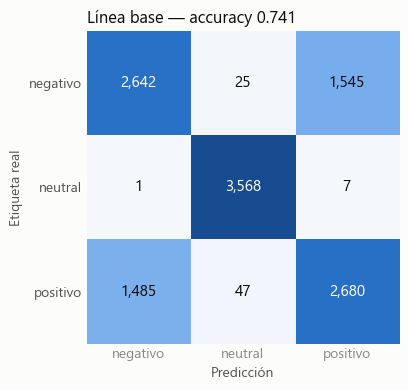

In [8]:
def graficar_confusion(ax, y_true, y_pred, titulo):
    cm = confusion_matrix(y_true, y_pred, labels=CLASES)
    ax.imshow(cm, cmap=RAMPA_AZUL, vmin=0, vmax=cm.sum(1).max())
    for i in range(3):
        for j in range(3):
            oscuro = cm[i, j] > 0.55 * cm.sum(1).max()
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', fontsize=11, color='white' if oscuro else TINTA)
    ax.set_xticks(range(3), CLASES); ax.set_yticks(range(3), CLASES)
    ax.set_xlabel('Predicción'); ax.set_ylabel('Etiqueta real')
    ax.set_title(titulo, color=TINTA)
    ax.tick_params(length=0)
    for s in ax.spines.values(): s.set_visible(False)

fig, ax = plt.subplots(figsize=(4.6, 4))
graficar_confusion(ax, y, pred_base, f'Línea base — accuracy {accuracy_score(y, pred_base):.3f}')
plt.tight_layout(); plt.show()

**Diagnóstico:** la clase `neutral` está prácticamente resuelta (~99.8 % de recall), pero entre `positivo` y `negativo` la línea base acierta solo ≈63 %. Casi todo el error son confusiones positivo↔negativo en **reseñas mixtas**: la bolsa de palabras ve *"excelente"* y *"pésimo"* a la vez y no sabe cuál pesa más, porque descarta el orden.

## 5. Análisis del error: ¿qué opinión decide la etiqueta?
Para entender la regla que siguen las reseñas mixtas:
1. Partimos cada reseña en **cláusulas** (oraciones, y dentro de ellas en *", pero"*, *", aunque"*, *", y"*, …).
2. Entrenamos, dentro de cada fold y sin mirar el fold de validación, dos modelos auxiliares a nivel de documento: un **detector de opinión** (reseña polar frente a neutral) y un **modelo de polaridad** (positivo frente a negativo). Aplicados a cada cláusula, indican cuáles expresan opinión y con qué signo.
3. En las reseñas con opiniones de signo contrario medimos con qué frecuencia la etiqueta coincide con la **primera** opinión, con la **última** o con la **más intensa**, según el conector que introduce la última opinión.

In [9]:
FUERTES = ['pero al final', 'pero', 'aun asi', 'aun con eso', 'con todo', 'al final de cuentas', 'al final',
           'a fin de cuentas', 'sin embargo', 'no obstante', 'de todos modos', 'de todas formas', 'lo que si',
           'ahora bien', 'aunque']                        # conectores adversativos "fuertes"
DEBILES = ['eso si', 'igual', 'total', 'en fin', 'en cambio']   # adversativos "débiles"
ADITIVOS = ['por otro lado', 'por otra parte', 'ademas', 'de paso', 'por cierto', 'tambien', 'y']

def oraciones(t):
    return [s for s in re.split(r'(?<=[.!?])\s+', t) if s] or ['']

RE_CLAUSULA = re.compile(r',\s*(?=(?:pero|aunque|y|eso si|en cambio|sin embargo|mientras que|aun asi)\b)|;\s*')
def clausulas(t):
    return [p.strip() for s in oraciones(t) for p in RE_CLAUSULA.split(s) if p.strip()]

RE_CONECTOR = re.compile(r'\b(' + '|'.join(re.escape(c) for c in sorted(FUERTES + DEBILES + ADITIVOS, key=len, reverse=True)) + r')\b')
def conector_de(clausula):
    m = RE_CONECTOR.search(clausula[:45])
    return m.group(1) if m else '(sin conector)'

def grupo_de(conector):
    if conector in FUERTES: return 'adversativo fuerte'
    if conector in DEBILES: return 'adversativo débil'
    return 'aditivo / sin conector'

Xn = np.array([normalizar(t) for t in X])
filas = []
for tr_idx, va_idx in CV.split(Xn, y):
    v_op = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2)
    detector = LogisticRegression(C=5, max_iter=5000).fit(v_op.fit_transform(Xn[tr_idx]), y[tr_idx] != 'neutral')
    polares = tr_idx[y[tr_idx] != 'neutral']
    v_pol = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2)
    polaridad = LogisticRegression(C=5, max_iter=5000).fit(v_pol.fit_transform(Xn[polares]), y[polares] == 'positivo')

    idx = [i for i in va_idx if y[i] != 'neutral']
    cls = [clausulas(Xn[i]) for i in idx]
    planas = [c for cc in cls for c in cc]
    s_op = detector.decision_function(v_op.transform(planas)) - detector.intercept_[0]
    s_pol = polaridad.decision_function(v_pol.transform(planas))
    k = 0
    for i, cc in zip(idx, cls):
        so, sp = s_op[k:k + len(cc)], s_pol[k:k + len(cc)]; k += len(cc)
        ops = [(c, p) for c, o, p in zip(cc, so, sp) if o > 3]          # cláusulas con opinión
        if len(ops) < 2 or np.sign(ops[0][1]) == np.sign(ops[-1][1]) or min(abs(ops[0][1]), abs(ops[-1][1])) < 1:
            continue                                                    # solo reseñas mixtas claras
        es_pos = y[i] == 'positivo'
        mas_intensa = ops[0][1] if abs(ops[0][1]) > abs(ops[-1][1]) else ops[-1][1]
        con = conector_de(ops[-1][0])
        filas.append(dict(conector=con, grupo=grupo_de(con), primera=es_pos == (ops[0][1] > 0),
                          ultima=es_pos == (ops[-1][1] > 0), intensa=es_pos == (mas_intensa > 0)))

mixtas = pd.DataFrame(filas)
print(f'Reseñas mixtas analizadas: {len(mixtas)} de {(y != "neutral").sum()} polares\n')
agg = dict(n=('ultima', 'size'), etiqueta_igual_primera=('primera', 'mean'),
           etiqueta_igual_ultima=('ultima', 'mean'), etiqueta_igual_mas_intensa=('intensa', 'mean'))
por_grupo = mixtas.groupby('grupo').agg(**agg).round(3)
por_conector = mixtas.groupby(['conector', 'grupo']).agg(**agg).query('n >= 12').sort_values('etiqueta_igual_ultima', ascending=False).round(3)
display(por_grupo)
display(por_conector)

Reseñas mixtas analizadas: 1701 de 8424 polares



,n,etiqueta_igual_primera,etiqueta_igual_ultima,etiqueta_igual_mas_intensa
grupo,,,,
aditivo / sin conector,1039,0.480,0.520,0.494
adversativo débil,387,0.388,0.612,0.545
adversativo fuerte,275,0.084,0.916,0.636


,,n,etiqueta_igual_primera,etiqueta_igual_ultima,etiqueta_igual_mas_intensa
conector,grupo,,,,
con todo,adversativo fuerte,23,0.043,0.957,0.522
pero al final,adversativo fuerte,20,0.050,0.950,1.000
aun asi,adversativo fuerte,78,0.051,0.949,0.513
pero,adversativo fuerte,64,0.094,0.906,0.797
aunque,adversativo fuerte,32,0.094,0.906,0.688
al final,adversativo fuerte,21,0.143,0.857,0.571
lo que si,adversativo fuerte,16,0.188,0.812,0.688
igual,adversativo débil,16,0.250,0.750,0.750
y,aditivo / sin conector,48,0.292,0.708,0.438


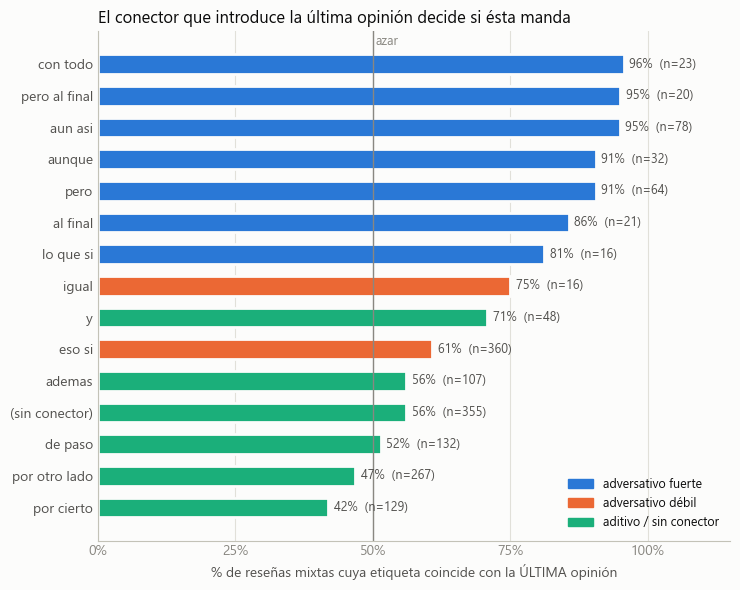

In [10]:
COLOR_GRUPO = {'adversativo fuerte': AZUL, 'adversativo débil': NARANJA, 'aditivo / sin conector': AQUA}
d = por_conector.reset_index().sort_values('etiqueta_igual_ultima')
fig, ax = plt.subplots(figsize=(7.5, 0.32 * len(d) + 1.2))
ax.barh(d.conector, 100 * d.etiqueta_igual_ultima, height=0.62, color=[COLOR_GRUPO[g] for g in d.grupo],
        edgecolor=SUPERFICIE, linewidth=2)
for yy, (v, n) in enumerate(zip(d.etiqueta_igual_ultima, d.n)):
    ax.text(100 * v + 1, yy, f'{100 * v:.0f}%  (n={n})', va='center', fontsize=9, color=TINTA2)
ax.axvline(50, color=TENUE, linewidth=1)
ax.text(50.5, len(d) - 0.4, 'azar', color=TENUE, fontsize=9)
ax.set_xlim(0, 115); ax.set_xticks([0, 25, 50, 75, 100], ['0%', '25%', '50%', '75%', '100%'])
ax.xaxis.grid(True); ax.set_axisbelow(True); ax.tick_params(length=0)
ax.set_xlabel('% de reseñas mixtas cuya etiqueta coincide con la ÚLTIMA opinión')
ax.set_title('El conector que introduce la última opinión decide si ésta manda', color=TINTA)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in COLOR_GRUPO.values()], labels=list(COLOR_GRUPO),
          loc='lower right', frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

**Hallazgos:**
- Con un **conector adversativo fuerte** (*con todo, aun así, pero al final, aunque, pero…*) la etiqueta sigue a la **última** opinión en el 92 % de los casos: es la regla de *recencia* que menciona el enunciado.
- Con *"eso sí"* (el conector más frecuente) la última opinión gana solo el 61 % de las veces.
- Con conectores **aditivos** (*por otro lado, además, de paso, por cierto*) o sin conector, la etiqueta coincide con la primera opinión el 48 % de las veces, con la última el 52 % y con la más intensa el 49 %: con este detector de cláusulas **no aparece ninguna señal de orden**.

**Consecuencias para el modelado:**
1. La representación debe saber **dónde** aparece cada palabra: antes o después del último conector adversativo, y si está en la última oración (sección 6).
2. Una parte de las reseñas mixtas parece impredecible. En la sección 9, con un análisis más fino de las plantillas, veremos que la explicación no es el conector sino el **tipo de opinión**, y cuantificaremos el ruido irreducible.

## 6. Representación consciente del orden: bloques de texto
El transformador `Bloques` (sin parámetros entrenables) convierte cada reseña en varias "vistas" del texto, y **cada bloque se vectoriza por separado con TF-IDF**. Así la misma palabra pesa distinto según dónde aparece: *"pésimo"* en el segmento que sigue a *"aun así"* pesa mucho más que *"pésimo"* antes del conector.

| Bloque | Contenido |
|---|---|
| `completo` | toda la reseña normalizada (bolsa de palabras clásica) |
| `post` | desde el **último conector adversativo** (fuerte o débil) hasta el final |
| `post_fuerte` | desde el último conector adversativo **fuerte** hasta el final |
| `post_debil` | desde el último conector adversativo **débil** (*eso sí, igual…*) hasta el final |
| `ultima` | la última oración |
| `penultima` | la penúltima oración |

Sigue siendo una representación de bolsa de palabras y n-gramas: solo cambia **qué fragmento** se vectoriza.

In [11]:
def _regex_conectores(lista):
    # Conector al inicio del texto o después de un signo de puntuación
    return re.compile(r'(?:^|(?<=[.!?,;])\s*)(?:' + '|'.join(re.escape(c) for c in sorted(lista, key=len, reverse=True)) + r')\b')

RE_FUERTE, RE_DEBIL, RE_ADVERSATIVO = _regex_conectores(FUERTES), _regex_conectores(DEBILES), _regex_conectores(FUERTES + DEBILES)

def desde_ultimo(texto, regex):
    # Fragmento desde la última aparición del conector hasta el final ('' si no hay conector)
    m = list(regex.finditer(texto))
    return texto[m[-1].start():] if m else ''


class Bloques(TransformerMixin, BaseEstimator):
    # Convierte textos crudos en un DataFrame con una columna de texto por bloque
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        T = [normalizar(t) for t in X]
        O = [oraciones(t) for t in T]
        return pd.DataFrame({
            'completo': T,
            'post': [desde_ultimo(t, RE_ADVERSATIVO) for t in T],
            'post_fuerte': [desde_ultimo(t, RE_FUERTE) for t in T],
            'post_debil': [desde_ultimo(t, RE_DEBIL) for t in T],
            'ultima': [o[-1] for o in O],
            'penultima': [o[-2] if len(o) > 1 else '' for o in O],
        })


ejemplo = train.text[2]
print(ejemplo, '\n')
Bloques().transform([ejemplo]).T.rename(columns={0: 'contenido'})

Lo pedí a mediados de mes y me llegó en tres días, en su caja normal sin nada fuera de lo común. Lo uso en la oficina casi a diario desde entonces. El diseño se sintió durable desde el primer día. Aun así, la relación calidad-precio se ve desagradable con el tiempo. 



,contenido
completo,"lo pedi a mediados de mes y me llego en tres dias, en su caja normal sin nada fuera de lo comun. lo uso en la oficina casi a diario desde entonces. el diseno se sintio durable desde el primer dia...."
post,"aun asi, la relacion calidad-precio se ve desagradable con el tiempo."
post_fuerte,"aun asi, la relacion calidad-precio se ve desagradable con el tiempo."
post_debil,
ultima,"aun asi, la relacion calidad-precio se ve desagradable con el tiempo."
penultima,el diseno se sintio durable desde el primer dia.


In [12]:
B = Bloques().transform(X)
print('% de reseñas con conector adversativo fuerte:', round(100 * (B.post_fuerte != '').mean(), 1))
print('% de reseñas con conector adversativo débil :', round(100 * (B.post_debil != '').mean(), 1))

% de reseñas con conector adversativo fuerte: 26.0
% de reseñas con conector adversativo débil : 17.6


## 7. Modelos base del ensemble v1
Todos se evalúan con la **misma** validación cruzada y guardamos sus probabilidades OOF para construir después el ensemble sin fuga de información.

- **`lr_palabras`**: TF-IDF de palabras (1-2 gramas) en los bloques `completo`, `post` y `ultima` + regresión logística.
- **`lr_pal_car`**: lo mismo con n-gramas de caracteres (`char_wb`, 2-5) en cada bloque: robusto a typos y tildes faltantes.
- **`svc_pal_car`**: misma representación con SVM lineal; `CalibratedClassifierCV` le da probabilidades para el voto suave.
- **`stacking`**: una regresión logística **por bloque** (los 6 bloques, palabras + caracteres) y un **HistGradientBoosting** como meta-clasificador sobre sus probabilidades. Al no ser lineal, el meta-modelo aprende reglas como *"si el bloque tras el conector fuerte es muy negativo, ignorar lo anterior"*. `StackingClassifier` genera internamente las predicciones de los modelos base por validación cruzada, así que el meta-modelo no ve predicciones sobreajustadas.

Los hiperparámetros (C de la regresión logística en {2, 5, 10, 20}, C del SVM en {0.1, 0.3, 1}, rangos de n-gramas, bloques) se eligieron con esta misma validación cruzada; una búsqueda aleatoria posterior de 87 configuraciones confirmó que ya eran óptimos (±0.1 pts).

In [13]:
def tfidf_palabras():
    return TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2)

def tfidf_caracteres():
    return TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), sublinear_tf=True, min_df=3)

def vectorizar(bloques, vectorizadores):
    # Un vectorizador independiente por cada (bloque, tipo de n-grama)
    return ColumnTransformer([(f'{b}_{i}', v(), b) for b in bloques for i, v in enumerate(vectorizadores)])

BLOQUES_LINEALES = ['completo', 'post', 'ultima']
BLOQUES_STACKING = ['completo', 'post', 'post_fuerte', 'post_debil', 'ultima', 'penultima']

def modelo_lr_palabras():
    return Pipeline([('bloques', Bloques()),
                     ('vec', vectorizar(BLOQUES_LINEALES, [tfidf_palabras])),
                     ('clf', LogisticRegression(C=5, max_iter=5000))])

def modelo_lr_pal_car():
    return Pipeline([('bloques', Bloques()),
                     ('vec', vectorizar(BLOQUES_LINEALES, [tfidf_palabras, tfidf_caracteres])),
                     ('clf', LogisticRegression(C=5, max_iter=5000))])

def modelo_svc_pal_car():
    return Pipeline([('bloques', Bloques()),
                     ('vec', vectorizar(BLOQUES_LINEALES, [tfidf_palabras, tfidf_caracteres])),
                     ('clf', CalibratedClassifierCV(LinearSVC(C=0.3, random_state=SEED), cv=3))])

def modelo_stacking():
    por_bloque = [(b, Pipeline([('vec', vectorizar([b], [tfidf_palabras, tfidf_caracteres])),
                                ('clf', LogisticRegression(C=5, max_iter=5000))]))
                  for b in BLOQUES_STACKING]
    meta = HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300, max_leaf_nodes=15, min_samples_leaf=40,
                                          early_stopping=False, random_state=0)
    return Pipeline([('bloques', Bloques()),
                     ('stack', StackingClassifier(por_bloque, final_estimator=meta, stack_method='predict_proba',
                                                  cv=StratifiedKFold(5, shuffle=True, random_state=1)))])

FABRICAS_V1 = {'stacking': modelo_stacking, 'lr_palabras': modelo_lr_palabras,
               'lr_pal_car': modelo_lr_pal_car, 'svc_pal_car': modelo_svc_pal_car}

pd.DataFrame({
    'bloques': [', '.join(BLOQUES_STACKING)] + [', '.join(BLOQUES_LINEALES)] * 3,
    'n-gramas': ['palabras 1-2 + caracteres 2-5', 'palabras 1-2', 'palabras 1-2 + caracteres 2-5',
                 'palabras 1-2 + caracteres 2-5'],
    'clasificador': ['6 LR (una por bloque) -> HistGradientBoosting', 'LogisticRegression(C=5)',
                     'LogisticRegression(C=5)', 'LinearSVC(C=0.3) calibrado'],
}, index=list(FABRICAS_V1))

,bloques,n-gramas,clasificador
stacking,"completo, post, post_fuerte, post_debil, ultima, penultima",palabras 1-2 + caracteres 2-5,6 LR (una por bloque) -> HistGradientBoosting
lr_palabras,"completo, post, ultima",palabras 1-2,LogisticRegression(C=5)
lr_pal_car,"completo, post, ultima",palabras 1-2 + caracteres 2-5,LogisticRegression(C=5)
svc_pal_car,"completo, post, ultima",palabras 1-2 + caracteres 2-5,LinearSVC(C=0.3) calibrado


In [14]:
OOF = {}            # probabilidades out-of-fold de cada componente con la partición 42
SEGUNDOS = {}
for nombre, fabrica in FABRICAS_V1.items():
    t0 = time.time()
    OOF[nombre] = cross_val_predict(fabrica(), X, y, cv=CV, method='predict_proba', n_jobs=N_JOBS)
    SEGUNDOS[nombre] = time.time() - t0
    print(f'{nombre:12s} accuracy CV = {accuracy_score(y, CLASES[OOF[nombre].argmax(1)]):.4f}   ({SEGUNDOS[nombre]:.0f} s)')

def acc_oof(P):
    return accuracy_score(y, CLASES[np.asarray(P).argmax(1)])

stacking     accuracy CV = 0.9012   (282 s)


lr_palabras  accuracy CV = 0.8951   (10 s)


lr_pal_car   accuracy CV = 0.8981   (42 s)


svc_pal_car  accuracy CV = 0.8998   (42 s)


## 8. Ensemble v1: voto suave ponderado
El ensemble promedia las probabilidades de los modelos con pesos $w_i \ge 0$, $\sum_i w_i = 1$:

$$\hat{p}(c \mid x) = \sum_i w_i \, p_i(c \mid x), \qquad \hat{y} = \arg\max_c \hat{p}(c \mid x)$$

Buscamos los pesos en una **rejilla de paso 0.1** maximizando la accuracy de las probabilidades OOF. Como elegir pesos mirando esas mismas OOF puede sobreajustar, estimamos además la **accuracy con selección anidada**: elegimos los pesos con 4/5 de las filas OOF y medimos en el 1/5 restante (`StratifiedKFold(5, shuffle=True, random_state=123)` sobre las filas). Las funciones de esta celda se reutilizan con los 6 componentes en la sección 12.

In [15]:
# Herramientas para combinar modelos a partir de sus probabilidades OOF (se reutilizan en las secciones 12 y 13)
from functools import lru_cache


@lru_cache(maxsize=None)
def rejilla_pesos(k, paso=0.1):
    # Todas las combinaciones de k pesos múltiplos de `paso` que suman 1, en orden lexicográfico
    n = int(round(1 / paso))
    return np.array([c for c in itertools.product(range(n + 1), repeat=k) if sum(c) == n], dtype=float) / n


def apilar(P):
    nombres = list(P)
    return nombres, np.stack([np.asarray(P[n], dtype=float) for n in nombres])     # (k, N, 3)


def prob_ensemble(P, pesos):
    # Voto suave: suma ponderada de las probabilidades de los componentes
    nombres, A = apilar({n: P[n] for n in pesos})
    return np.tensordot(np.array([pesos[n] for n in nombres]), A, axes=1)


def mejores_pesos(P, y, filas=None, paso=0.1):
    """Combinación de la rejilla con mayor accuracy sobre las OOF (opcionalmente, solo en `filas`).
    Ante empates gana la primera en orden lexicográfico. Devuelve (pesos, accuracy, rejilla, accuracy de cada fila)."""
    nombres, A = apilar(P)
    yi = np.searchsorted(CLASES, y)
    if filas is not None:
        A, yi = A[:, filas], yi[filas]
    W = rejilla_pesos(len(nombres), paso)
    acc = np.array([(np.tensordot(w, A, axes=1).argmax(1) == yi).mean() for w in W])
    i = int(np.argmax(acc))
    return dict(zip(nombres, map(float, W[i]))), float(acc[i]), W, acc


def seleccion_anidada(P, y, semilla=123, paso=0.1):
    """Validación anidada de la selección de pesos: se eligen con 4/5 de las filas OOF y se mide la accuracy en el
    1/5 restante, 5 veces. Estima cuánto rinden los pesos elegidos en reseñas que no participaron en elegirlos."""
    filas = []
    for a, b in StratifiedKFold(5, shuffle=True, random_state=semilla).split(y, y):
        pesos, _, _, _ = mejores_pesos(P, y, a, paso)
        P_b = prob_ensemble({n: np.asarray(P[n])[b] for n in P}, pesos)
        filas.append({**pesos, 'accuracy_parte_no_vista': accuracy_score(y[b], CLASES[P_b.argmax(1)])})
    return pd.DataFrame(filas)


def mcnemar(pred_nuevo, pred_base, y):
    # Prueba exacta de McNemar (binomial de dos colas) sobre las reseñas en que los dos modelos discrepan en acierto
    a, b = (pred_nuevo == y), (pred_base == y)
    gana, pierde = int((a & ~b).sum()), int((~a & b).sum())
    n, k = gana + pierde, min(gana, pierde)
    p = min(1.0, 2 * sum(math.comb(n, i) for i in range(k + 1)) / 2 ** n) if n else 1.0
    return dict(gana=gana, pierde=pierde, p=p)


def oof_por_fold(crear_modelo, X, y, cv, n_jobs=N_JOBS):
    """Igual que cross_val_predict(..., method='predict_proba'): para cada fold k entrena crear_modelo(k) con el
    resto de los datos y predice el fold. La única diferencia es que el modelo puede depender de k."""
    y_cod = LabelEncoder().fit(CLASES).transform(y)          # etiquetas 0/1/2, como hace cross_val_predict

    def un_fold(k, entrenamiento, validacion):
        modelo = crear_modelo(k).fit(X[entrenamiento], y_cod[entrenamiento])
        return validacion, modelo.predict_proba(X[validacion])

    P = np.zeros((len(y), len(CLASES)))
    tareas = (delayed(un_fold)(k, a, b) for k, (a, b) in enumerate(cv.split(X, y)))
    for validacion, Pk in Parallel(n_jobs=n_jobs)(tareas):
        P[validacion] = Pk
    return P


print(f'Rejilla de paso 0.1: {len(rejilla_pesos(4))} combinaciones con 4 componentes y {len(rejilla_pesos(6))} con 6')

Rejilla de paso 0.1: 286 combinaciones con 4 componentes y 3003 con 6


In [16]:
NOMBRES_V1 = list(FABRICAS_V1)
aciertos = pd.DataFrame({n: CLASES[OOF[n].argmax(1)] == y for n in NOMBRES_V1})
print('Correlación de aciertos entre modelos (más baja = más complementarios):')
display(aciertos.corr().round(2))

OOF_V1 = {n: OOF[n] for n in NOMBRES_V1}
pesos_v1, oof_v1, W4, acc_W4 = mejores_pesos(OOF_V1, y)
mejores = np.argsort(-acc_W4, kind='stable')[:10]
print(f'Combinaciones evaluadas: {len(W4)}. Las 10 mejores:')
display(pd.DataFrame(W4[mejores], columns=NOMBRES_V1).assign(accuracy_oof=acc_W4[mejores].round(4)))

Correlación de aciertos entre modelos (más baja = más complementarios):


,stacking,lr_palabras,lr_pal_car,svc_pal_car
stacking,1.00,0.54,0.56,0.56
lr_palabras,0.54,1.00,0.82,0.82
lr_pal_car,0.56,0.82,1.00,0.86
svc_pal_car,0.56,0.82,0.86,1.00


Combinaciones evaluadas: 286. Las 10 mejores:


,stacking,lr_palabras,lr_pal_car,svc_pal_car,accuracy_oof
0,0.5,0.4,0.0,0.1,0.9069
1,0.5,0.3,0.1,0.1,0.9067
2,0.5,0.3,0.0,0.2,0.9066
3,0.5,0.4,0.1,0.0,0.9063
4,0.5,0.5,0.0,0.0,0.9063
5,0.5,0.2,0.2,0.1,0.9060
6,0.5,0.2,0.0,0.3,0.9058
7,0.5,0.3,0.2,0.0,0.9058
8,0.6,0.4,0.0,0.0,0.9058
9,0.5,0.2,0.1,0.2,0.9057


In [17]:
anidado_v1 = seleccion_anidada(OOF_V1, y)
display(anidado_v1.round(4))
pred_v1 = CLASES[prob_ensemble(OOF_V1, pesos_v1).argmax(1)]

PESOS_ENVIADOS = {'stacking': 0.5, 'lr_palabras': 0.1, 'lr_pal_car': 0.3, 'svc_pal_car': 0.1}   # submission.csv
oof_v1_enviado = acc_oof(prob_ensemble(OOF_V1, PESOS_ENVIADOS))
print(f'Ensemble v1: accuracy OOF {oof_v1:.4f} con pesos {pesos_v1}')
print(f'             selección de pesos anidada {anidado_v1.accuracy_parte_no_vista.mean():.4f}')
print(f'Pesos del modelo enviado a Kaggle {PESOS_ENVIADOS}: accuracy OOF {oof_v1_enviado:.4f}')

,stacking,lr_palabras,lr_pal_car,svc_pal_car,accuracy_parte_no_vista
0,0.5,0.4,0.0,0.1,0.9029
1,0.5,0.4,0.0,0.1,0.9108
2,0.5,0.3,0.1,0.1,0.9071
3,0.5,0.4,0.0,0.1,0.9129
4,0.5,0.4,0.0,0.1,0.8996


Ensemble v1: accuracy OOF 0.9069 con pesos {'stacking': 0.5, 'lr_palabras': 0.4, 'lr_pal_car': 0.0, 'svc_pal_car': 0.1}
             selección de pesos anidada 0.9067
Pesos del modelo enviado a Kaggle {'stacking': 0.5, 'lr_palabras': 0.1, 'lr_pal_car': 0.3, 'svc_pal_car': 0.1}: accuracy OOF 0.9054


**Interpretación:** la superficie de pesos es muy plana: las 10 mejores combinaciones difieren en apenas 0.12 puntos y la selección anidada (0.9067) queda prácticamente igual que la accuracy OOF (0.9069). El modelo enviado a Kaggle (`submission.csv`, **0.90111** en la tabla pública) usaba los pesos 0.5 / 0.1 / 0.3 / 0.1, elegidos en una ejecución anterior; con las OOF de esta ejecución esos pesos dan 0.9054, la misma accuracy dentro del ruido.

**Nota sobre reproducibilidad numérica.** Con el mismo código y la misma partición, la accuracy OOF del stacking fue 0.8973 en el notebook de v1 (`modelo_sentimiento.ipynb`, sin fijar hilos), 0.8983 con 6 hilos de BLAS por proceso y 0.9012 aquí (4 hilos). Lo comprobamos aparte: con 6 hilos la OOF se reproduce exactamente, predicción por predicción. No es un error sino sensibilidad numérica: el meta-HistGradientBoosting corta sobre probabilidades de regresiones logísticas cuyos coeficientes cambian en el último bit, y unas pocas reseñas cerca de un umbral cambian de lado. La consecuencia práctica es que las diferencias de hasta 3-4 décimas entre ensembles son del orden de este ruido; la mejora de v3b frente a v1 (≈ +1 punto) es bastante mayor.

¿Dónde se equivoca v1? Agrupando las reseñas por el tipo de conector:

In [18]:
tipo = np.select([y == 'neutral', B.post_fuerte != '', B.post_debil != '',
                  B.completo.str.contains(r'\b(?:por otro lado|por otra parte|ademas|de paso|por cierto|tambien)\b')],
                 ['neutral', 'con adversativo fuerte', 'con adversativo débil (eso sí…)', 'con conector aditivo'],
                 default='sin conector')
pd.DataFrame({'tipo': tipo, 'base': pred_base == y, 'v1': pred_v1 == y}).groupby('tipo').agg(
    n=('base', 'size'), acc_linea_base=('base', 'mean'), acc_ensemble_v1=('v1', 'mean'),
    errores_v1=('v1', lambda s: int((~s).sum()))).round(3).sort_values('acc_ensemble_v1', ascending=False)

,n,acc_linea_base,acc_ensemble_v1,errores_v1
tipo,,,,
neutral,3576,0.998,0.997,9
con adversativo fuerte,2917,0.585,0.971,85
sin conector,2650,0.737,0.892,285
con adversativo débil (eso sí…),1657,0.566,0.804,325
con conector aditivo,1200,0.604,0.656,413


v1 resuelve casi por completo las reseñas con conector adversativo fuerte y las neutrales. Los ~1 100 errores restantes se concentran en reseñas con *"eso sí"*, con conectores aditivos o sin conector. La siguiente sección explica por qué.

## 9. Hallazgo: dos familias de plantillas
Leyendo cientos de errores de v1 se ve que el corpus es **sintético**: cada reseña combina frases de relleno (envío, peso, garantía, *"la verdad"*) con 1-3 opiniones, y las opiniones salen de **dos plantillas** distintas:

| Familia | Forma | Ejemplos |
|---|---|---|
| **A** (adjetival) | *[aspecto] + verbo copulativo + (modificador) + ADJETIVO* | *"la batería se mantuvo buenísima"*, *"la portabilidad se ve floja"*, *"el diseño se sintió durable"* |
| **B** (frase hecha) | expresión fija sobre el producto | *"superó todas mis expectativas"*, *"no vale lo que cuesta"*, *"fue todo un acierto"* |

Para medir qué decide la etiqueta escribimos un **parser determinista** de esas plantillas (dos celdas siguientes): un inventario hecho a mano de verbos copulativos, adjetivos (con modificadores y negación: *"poco fiable"*, *"no es cómodo"*), frases hechas, conectores y cierres ambivalentes (*"cada quien que juzgue"*, *"ni fu ni fa"*), más un **corrector de typos** por distancia de edición. Este mismo parser es la base del componente `estructural` (sección 10).

En esta sección lo usamos solo para **describir** los datos: la polaridad de cada opinión es la semántica del inventario (prefijo `p_`/`a+` positivo, `n_`/`a-` negativo) y el corrector solo cuenta palabras, así que el análisis no ajusta nada a las etiquetas.

In [19]:
# ---------------------------------------------------------------- corrector de typos (se ajusta en cada fold)
LETRAS = 'abcdefghijklmnopqrstuvwxyzñ'


def _ediciones1(w):
    # Todas las cadenas a distancia de edición 1 de w: borrado, transposición, sustitución e inserción
    cortes = [(w[:i], w[i:]) for i in range(len(w) + 1)]
    borrados = [a + b[1:] for a, b in cortes if b]
    transpuestos = [a + b[1] + b[0] + b[2:] for a, b in cortes if len(b) > 1]
    sustituidos = [a + c + b[1:] for a, b in cortes if b for c in LETRAS]
    insertados = [a + c + b for a, b in cortes for c in LETRAS]
    return set(borrados + transpuestos + sustituidos + insertados)


class CorrectorTypos:
    """Cambia cada palabra rara (< min_frec apariciones en los textos de entrenamiento, más de 3 letras) por la
    palabra frecuente más común a distancia de edición 1: 'lleego' -> 'llego', 'epsectacular' -> 'espectacular'."""

    def __init__(self, min_frec=5):
        self.min_frec = min_frec

    def fit(self, textos_normalizados):
        self.frecuencia = collections.Counter(w for t in textos_normalizados for w in re.findall(r'[a-zñ]+', t))
        self.vocabulario = {w for w, k in self.frecuencia.items() if k >= self.min_frec}
        self.cache = {}
        return self

    def palabra(self, w):
        if w in self.vocabulario or len(w) <= 3:
            return w
        if w not in self.cache:
            # candidatas en orden alfabético: el desempate entre frecuencias iguales no depende del azar del hash
            candidatas = sorted(v for v in _ediciones1(w) if v in self.vocabulario)
            self.cache[w] = max(candidatas, key=lambda v: self.frecuencia[v]) if candidatas else w
        return self.cache[w]

    def transform(self, texto):
        return re.sub(r'[a-zñ]+', lambda m: self.palabra(m.group()), texto)


# ---------------------------------------------------------------- inventario de las plantillas (escrito a mano)
# Plantilla A: "[aspecto] + verbo copulativo + (modificador) + ADJETIVO", p. ej. "la batería se mantuvo buenísima"
COPULAS = ['me parecio', 'me resulto ser', 'me resulto', 'resulto ser', 'resulto', 'quedo', 'se ve', 'se siente',
           'se sintio', 'se mantuvo', 'termino siendo', 'luce', 'es', 'esta', 'fue', 'me salio', 'salio',
           'me quedo', 'anda', 'se nota', 'se volvio', 'funciona', 'sigue siendo', 'sigue', 'me parece', 'parece',
           'me ha parecido', 'se ha mantenido', 'me termino pareciendo', 'termino pareciendo', 'vino', 'me resulta',
           'resulta', 'queda', 'se sigue viendo', 'estuvo']
ADJETIVOS_POS = ['robust[oa]', 'correct[oa]', 'nitid[oa]', 'impecable', 'liger[oa]', 'sobresaliente', 'optim[oa]',
                 'redond[oa]', 'durable', 'resistente', 'excelente', 'espectacular', 'comodisim[oa]', 'superior',
                 'decente', 'potente', 'agradable', 'estupend[oa]', 'eficiente', 'fiable', 'practic[oa]', 'solid[oa]',
                 'buenisim[oa]', 'precis[oa]', 'confiable', 'cumplidor[a]?', 'formidable', 'comod[oa]',
                 'rapidisim[oa]', 'veloz', 'funcional', 'complet[oa]', 'buen[oa]', 'notable', 'bien hech[oa]',
                 'bien lograd[oa]', 'bien construid[oa]', 'bien terminad[oa]', 'lograd[oa]', 'de maravilla', 'genial',
                 'perfect[oa]', 'ideal', 'brillante', 'increible', 'fantastic[oa]', 'bien', 'de buena calidad',
                 'de calidad', 'muy buen[oa]']
ADJETIVOS_NEG = ['defectuos[oa]', 'imprecis[oa]', 'ordinari[oa]', 'incomod[oa]', 'chapucer[oa]', 'aparatos[oa]',
                 'terrible', 'inconsistente', 'malisim[oa]', 'floj[oa]', 'pobre', 'olvidable', 'debil',
                 'lentisim[oa]', 'limitad[oa]', 'inestable', 'torpe', 'deficiente', 'delicad[oa]', 'mediocre',
                 'basic[oa]', 'pesim[oa]', 'fragil', 'ruidos[oa]', 'incumplidor[a]?', 'desagradable', 'corriente',
                 'endeble', 'decepcionante', 'mal hech[oa]', 'mal terminad[oa]', 'mal construid[oa]', 'horrible',
                 'bastante mal', 'mal', 'lent[oa]', 'malo', 'mala', 'de mala calidad', 'de lo peor']
MODIFICADORES = r'(?:(?P<mod>muy|bastante|demasiado|super|algo|un poco|poco|nada|tan|re)\s+)?'
RE_ADJETIVO = re.compile(r'\b(?P<cop>' + '|'.join(sorted(COPULAS, key=len, reverse=True)) + r')\s+' + MODIFICADORES +
                         r'(?P<adj>' + '|'.join(sorted(ADJETIVOS_POS + ADJETIVOS_NEG, key=len, reverse=True)) + r')\b')
RE_ADJETIVO_POSITIVO = re.compile(r'^(?:' + '|'.join(ADJETIVOS_POS) + r')$')

# Plantilla B: frases hechas. El prefijo p_/n_ es su polaridad semántica (solo respaldo: la polaridad que usa el
# modelo se aprende en cada fold con las reseñas de entrenamiento que tienen una sola opinión).
FRASES_FIJAS = {
    'p_cumple_sobra': r'cumple de sobra',
    'p_vida_facil': r'me hizo la vida (?:mas|muy) facil',
    'p_sorprendio_bien': r'me sorprendio para bien',
    'p_cada_peso': r'cada peso que pague por .{0,40}? valio la pena|cada peso que pague valio la pena|valio cada peso',
    'p_me_encanto': r'\bme encanto\b|\bme encantaron\b',
    'p_feliz': r'\bestoy feliz con|\btermine feliz con|\bquede feliz con|me tiene feliz|me dejo feliz|estoy feliz|sigo estando feliz|feliz con',
    'p_contento': r'me tiene content[oa]|me dejo content[oa]|muy content[oa]|quede content[oa]|estoy content[oa]',
    'p_satisfecho': r'mas que satisfech[oa]|quede satisfech[oa]|muy satisfech[oa]',
    'p_repetiria': r'repetiria la compra',
    'p_recomiendo_sin': r'l[oa] recomiendo sin (?:pensarlo|dudarlo)|recomiendo .{0,30}?sin dudarlo',
    'p_mucho_mejor': r'mucho mejor de lo que',
    'p_me_alegra': r'me alegra haber elegido|me alegra haberl[oa] elegido|me alegra haberl[oa] comprado',
    'p_tal_como': r'respondio tal como esperaba|tal como esperaba',
    'p_sola_queja': r'ni una sola queja',
    'p_supero': r'supero todas mis expectativas|supero mis expectativas',
    'p_vale_pena': r'vale totalmente la pena|vale la pena',
    'p_cinco_estrellas': r'cinco estrellas',
    'p_ojos_cerrados': r'con los ojos cerrados',
    'p_encantado': r'quede encantad[oa] con|quede encantad[oa]|quedo encantad[oa]|me quedo encantad[oa]',
    'p_sin_pensarlo': r'volveria a comprar\w* .{0,40}?sin pensarlo|volveria a comprar\w* sin pensarlo|sin pensarlo dos veces',
    'p_justo_buscando': r'justo lo que (?:estaba buscando|buscaba|necesitaba)',
    'p_acierto': r'todo un acierto',
    'p_encima_media': r'por encima de la media',
    'p_maravilla': r'funciona de maravilla|de maravilla',
    'p_dejo_encantado': r'me dejo encantad[oa]|me tiene encantad[oa]',
    'p_volvi_comprar': r'volvi a comprar',
    'p_con_creces': r'cumple con creces|con creces',
    'p_ni_una_queja': r'ni una queja|una sola queja|no tengo queja|no me quejo',
    'p_me_gusto': r'me gusto (?:bastante|mucho)|me gustaron|me termino gustando|termino gustandome|si me gusto|me gusto',
    'n_no_vale': r'no vale lo que cuesta',
    'n_dolor_cabeza': r'mas de un dolor de cabeza|dolor de cabeza',
    'n_para_nada': r'no es para nada lo que esperaba|para nada lo que esperaba',
    'n_se_dano': r'se dano antes de lo que esperaba|se dano',
    'n_defraudo': r'defraudo todas mis expectativas|defraudo',
    'n_tire_dinero': r'tire el dinero',
    'n_decepciono': r'me decepciono|me decepcionaron',
    'n_me_arrepiento': r'me arrepiento de haber|me arrepiento es de haber|me arrepenti de haber\w*',
    'n_arrepentido': r'arrepentid[oa] de haber',
    'n_problemas': r'no pare de tener problemas|no para de darme problemas|no paro de darme problemas|me ha dado problemas',
    'n_no_convencio': r'no me convencio|no me convence|no me termino de convencer',
    'n_mal_rato': r'mas de un mal rato',
    'n_debajo_aceptable': r'por debajo de lo aceptable',
    'n_peor_parece': r'las cosas que peor',
    'n_molesto': r'quede muy molest[oa]|quede molest[oa]',
    'n_no_recomiendo': r'no l[oa] le recomiendo|no le recomiendo|no se l[oa]s? recomiendo|no l[oa] recomiendo|no se l[oa]s? recomendaria|recomendaria a nadie',
    'n_dejo_molesto': r'me dejo (?:muy )?molest[oa]',
    'n_complicaciones': r'me trajo complicaciones|me dio problemas|dio problemas|me trajo problemas',
    'n_no_funciono': r'no me funciono como esperaba|nunca me funciono como esperaba',
    'n_desilusiono': r'me desilusiono',
    'n_fue_error': r'fue un error',
    'n_una_estrella': r'una sola estrella|una estrella',
    'n_queda_corto': r'se queda muy cort[oa]|se queda cort[oa]',
    'n_ni_regalado': r'ni regalad[oa]|ni aunque me l[oa] regal\w*|ni me l[oa] regalaron',
    'n_harto': r'termine hart[oa]|quede hart[oa]|termino hart[oa]',
    'n_error_compra': r'un error de compra',
    'n_debajo_media': r'por debajo de la media',
    'n_bastante_mal': r'funciona bastante mal',
    'n_no_gusto': r'no me gusto nada|no me gusto',
    'n_de_lo_peor': r'de lo peor',
}
RE_FRASES_FIJAS = [(k, re.compile(r'\b(?:' + v + r')')) for k, v in FRASES_FIJAS.items()]

# Cierres ambivalentes: frases que dejan la decisión al lector (se buscan después de la última opinión)
CIERRES_AMBIVALENTES = {
    'c_juzgue': r'cada quien que juzgue|que cada quien juzgue|cada quien juzgue',
    'c_gustos': r'para gustos,? colores',
    'c_dudas': r'sigo con (?:dudas|la duda)|con la duda|me quede con la duda|sigo dudando|dudando',
    'c_fufa': r'ni fu ni fa',
    'c_criterio_cada': r'a criterio de cada uno',
    'c_criterio_tu': r'a tu criterio|a su criterio|a criterio',
    'c_no_sabria': r'no sabria (?:bien )?que (?:recomendar|pensar|decir)|no se bien que (?:pensar|decir|recomendar)|no se que (?:pensar|decir)',
    'c_hay_todo': r'hay de todo',
    'c_sopesalo': r'sopesalo|sopesenlo',
    'c_no_decido': r'no me decido|no me termino de decidir|sin decidirme|no termino de decidir',
    'c_mejor_peor': r'ni lo mejor ni lo peor',
    'c_bueno_malo': r'ni tan bueno ni tan malo',
    'c_ahi_dejo': r'ahi lo dejo|ahi queda',
    'c_sentimientos': r'sentimientos encontrados',
    'c_conclusiones': r'sacara sus conclusiones|saque sus conclusiones|sus propias conclusiones',
    'c_otras_no': r'otras no|lo uno y lo otro|unas cosas? (?:buenas?|mejor)|unos detalles mejor que otros',
    'c_vueltas': r'dandole vueltas|vuelta al asunto',
}
RE_CIERRES = [(k, re.compile(r'\b(?:' + v + r')')) for k, v in CIERRES_AMBIVALENTES.items()]

# Conectores que introducen una opinión (se buscan en el contexto inmediatamente anterior)
CONECTORES_PLANTILLA = {
    'fuerte': ['pero al final', 'pero', 'aun asi', 'aun con eso', 'con todo', 'al final de cuentas', 'al final',
               'a fin de cuentas', 'sin embargo', 'no obstante', 'de todos modos', 'de todas formas', 'lo que si',
               'ahora bien', 'aunque', 'el detalle es que', 'lo curioso es que', 'mientras que', 'eso no quita'],
    'debil': ['eso si', 'igual', 'total', 'en fin', 'en cambio', 'ahora'],
    'aditivo': ['por otro lado', 'por otra parte', 'ademas', 'de paso', 'por cierto', 'tambien', 'aparte',
                'encima', 'y'],
}
_LISTA_CONECTORES = sorted([(c, t) for t, cs in CONECTORES_PLANTILLA.items() for c in cs], key=lambda x: -len(x[0]))
RE_CONECTOR_PLANTILLA = re.compile(r'\b(' + '|'.join(re.escape(c) for c, _ in _LISTA_CONECTORES) + r')\b')
TIPO_CONECTOR_PLANTILLA = {c: t for c, t in _LISTA_CONECTORES}


print(f'Inventario: {len(COPULAS)} verbos copulativos, {len(ADJETIVOS_POS)} + {len(ADJETIVOS_NEG)} adjetivos (+/-), '
      f'{len(FRASES_FIJAS)} frases hechas, {len(CIERRES_AMBIVALENTES)} tipos de cierre ambivalente, '
      f'{len(TIPO_CONECTOR_PLANTILLA)} conectores')

Inventario: 36 verbos copulativos, 50 + 40 adjetivos (+/-), 59 frases hechas, 17 tipos de cierre ambivalente, 34 conectores


In [20]:
def oraciones_plantilla(t):
    return [s for s in re.split(r'(?<=[.!?])\s+', t.strip()) if s] or ['']


# Cortes dentro de una oración: comas, punto y coma, ' y ' seguido de un nuevo sujeto, y antes de pero/aunque
RE_FRAGMENTO = re.compile(r',\s+|;\s+|\s+y\s+(?=(?:el|la|los|las|lo|le|me|no|estoy|quede|siento|termine|recomiendo|'
                          r'volveria|cada|ni)\b)|\s+(?=(?:pero|aunque|mientras que|sin embargo)\b)')


def fragmentos_oracion(s):
    # Lista de (inicio, fin, separador previo) de los fragmentos de una oración
    salida, pos, sep = [], 0, ''
    for m in RE_FRAGMENTO.finditer(s):
        salida.append((pos, m.start(), sep))
        sep = m.group(0).strip() or ' '
        pos = m.end()
    salida.append((pos, len(s), sep))
    return [(a, b, sp) for a, b, sp in salida if s[a:b].strip(' .!?')]


def opiniones_fragmento(f):
    # Núcleos de opinión (clave, inicio, fin) de un fragmento, sin solapes; ante empate gana el más largo
    hallazgos = []
    for clave, rx in RE_FRASES_FIJAS:
        for m in rx.finditer(f):
            hallazgos.append((clave, m.start(), m.end()))
    for m in RE_ADJETIVO.finditer(f):
        adj = m.group('adj')
        # 'bien'/'mal' solos no cuentan tras es/está/fue/sigue (evita 'está bien empacado')
        if adj in ('bien', 'mal') and m.group('cop') in ('es', 'esta', 'fue', 'sigue'):
            continue
        signo = 'a+' if RE_ADJETIVO_POSITIVO.match(adj) else 'a-'
        mod = m.group('mod') or ''
        if mod in ('poco', 'nada'):                                     # 'poco fiable' invierte la polaridad
            signo = 'a-' if signo == 'a+' else 'a+'
        elif re.search(r'\bno\s+$', f[max(0, m.start() - 4):m.start()]):  # negación justo antes: 'no es cómodo'
            signo = 'a-' if signo == 'a+' else 'a+'
            mod = 'no'
        base = re.sub(r'[oa]$', '', adj) if ' ' not in adj else adj    # sin género: 'robust'
        hallazgos.append((f'{signo}:{mod + " " if mod in ("poco", "nada", "no") else ""}{base}', m.start(), m.end()))
    hallazgos.sort(key=lambda h: (h[1], -(h[2] - h[1])))
    salida, fin = [], -1
    for h in hallazgos:
        if h[1] >= fin:
            salida.append(h)
            fin = h[2]
    return salida


def analizar_resena(t):
    """t: texto normalizado y corregido. Devuelve las oraciones, la lista de opiniones (en orden) y el cierre."""
    S = oraciones_plantilla(t)
    opiniones = []
    for si, s in enumerate(S):
        fin_anterior = 0
        for a, b, sep in fragmentos_oracion(s):
            f = s[a:b]
            nucleos = opiniones_fragmento(f)
            if not nucleos:
                continue
            # varios núcleos en un mismo fragmento -> una opinión por núcleo (el fragmento se reparte)
            for j, (clave, ca, cb) in enumerate(nucleos):
                nb = nucleos[j + 1][1] if j + 1 < len(nucleos) else len(f)
                pa = nucleos[j - 1][2] if j > 0 else 0
                opiniones.append(dict(oracion=si, clave=clave, nucleo=f[ca:cb], inicio_fragmento=f[pa:ca],
                                      resto_fragmento=f[cb:nb], separador=sep if j == 0 else 'y',
                                      antes=s[fin_anterior:a] if j == 0 else '', ini=a + pa, fin=a + nb, oracion_texto=s))
            fin_anterior = b
    for j, o in enumerate(opiniones):
        # contexto posterior: desde el fin de la opinión hasta la siguiente opinión de la misma oración
        sig = opiniones[j + 1] if j + 1 < len(opiniones) and opiniones[j + 1]['oracion'] == o['oracion'] else None
        o['despues'] = o['oracion_texto'][o['fin']:(sig['ini'] if sig else len(o['oracion_texto']))]
        # conector: el último que aparece en el contexto inmediatamente anterior a la opinión
        conectores = RE_CONECTOR_PLANTILLA.findall(o['antes'] + ' ' + o['inicio_fragmento'] + ' ' + o['separador'])
        o['conector'] = conectores[-1] if conectores else ''
        o['tipo_conector'] = TIPO_CONECTOR_PLANTILLA.get(o['conector'], 'ninguno')
    # cierre ambivalente en una oración posterior a la última opinión...
    ultima_oracion = opiniones[-1]['oracion'] if opiniones else -1
    cierre, cierre_oracion = '', -1
    for si in range(len(S) - 1, ultima_oracion, -1):
        for clave, rx in RE_CIERRES:
            if rx.search(S[si]):
                cierre, cierre_oracion = clave, si
                break
        if cierre:
            break
    # ... o dentro de la misma oración, después de la última opinión
    cierre_en_linea = ''
    if opiniones and not cierre:
        for clave, rx in RE_CIERRES:
            if rx.search(opiniones[-1]['despues']):
                cierre_en_linea = clave
                break
    return dict(oraciones=S, opiniones=opiniones, cierre=cierre, cierre_oracion=cierre_oracion,
                cierre_en_linea=cierre_en_linea)


def polaridad_semantica(clave):
    return 1 if (clave.startswith('p_') or clave.startswith('a+')) else -1


def es_adjetival(opinion):
    return opinion['clave'][:2] in ('a+', 'a-')     # plantilla A (cópula + adjetivo) frente a frase hecha (B)


def tipo_de_final(analisis):
    # Qué hay después de la última opinión: 'opinion' (nada), 'relleno' (oraciones de hechos) o 'cierre' ambivalente
    S, ultima = analisis['oraciones'], analisis['opiniones'][-1]
    relleno = len(S) - 1 - ultima['oracion'] - (1 if analisis['cierre_oracion'] > ultima['oracion'] else 0)
    if analisis['cierre'] or analisis['cierre_en_linea']:
        return 'cierre', relleno
    return ('relleno' if relleno > 0 else 'opinion'), relleno


# Ejemplo sobre un texto ya normalizado
demo = analizar_resena('la bateria se mantuvo buenisima. aun asi, no vale lo que cuesta. cada quien que juzgue.')
for o in demo['opiniones']:
    print(f"opinión {'A' if es_adjetival(o) else 'B'}  clave {o['clave']:14s} núcleo {o['nucleo']!r:28s} "
          f"conector: {o['conector'] or '-'} ({o['tipo_conector']})")
print('cierre ambivalente:', demo['cierre'], '| la reseña termina en:', tipo_de_final(demo)[0])

opinión A  clave a+:buenisim    núcleo 'se mantuvo buenisima'       conector: - (ninguno)
opinión B  clave n_no_vale      núcleo 'no vale lo que cuesta'      conector: aun asi (fuerte)
cierre ambivalente: c_juzgue | la reseña termina en: cierre


In [21]:
corrector_eda = CorrectorTypos().fit([normalizar(t) for t in X])          # solo cuenta palabras: no usa etiquetas
ANALISIS = [analizar_resena(corrector_eda.transform(normalizar(t))) for t in X]

FAM_A, FAM_B, FAM_COH = 'mixta A (alguna opinión adjetival)', 'mixta B (solo frases hechas)', 'una opinión o todas del mismo signo'

def familia(a):
    # (familia, cómo termina, tipo de conector del último cambio de signo, signo de la última opinión)
    ops = a['opiniones']
    if not ops:
        return 'sin opinión detectada', '—', '—', 0
    signos = [polaridad_semantica(o['clave']) for o in ops]
    final, _ = tipo_de_final(a)
    if len(set(signos)) == 1:
        return FAM_COH, final, '—', signos[-1]
    j = [i for i in range(1, len(signos)) if signos[i] != signos[i - 1]][-1]
    return (FAM_A if any(es_adjetival(o) for o in ops) else FAM_B), final, ops[j]['tipo_conector'], signos[-1]

F = pd.DataFrame([familia(a) for a in ANALISIS], columns=['familia', 'final', 'conector', 'signo_ultima'])
F['etiqueta'] = y
F.loc[F.etiqueta == 'neutral', ['familia', 'final', 'conector']] = ['neutral', '—', '—']
F['gana_ultima'] = np.where((F.etiqueta == 'neutral') | (F.signo_ultima == 0), np.nan,
                            ((F.signo_ultima > 0) == (F.etiqueta == 'positivo')).astype(float))
F['acierto_v1'] = pred_v1 == y

ORDEN_FAMILIAS = ['neutral', 'sin opinión detectada', FAM_COH, FAM_A, FAM_B]
tabla_familias = (F.groupby(['familia', 'final'])
                   .agg(n=('etiqueta', 'size'), etiqueta_igual_ultima=('gana_ultima', 'mean'),
                        acierto_ensemble_v1=('acierto_v1', 'mean'), errores_v1=('acierto_v1', lambda s: int((~s).sum()))))
tabla_familias.insert(1, '% del train', 100 * tabla_familias.n / len(y))
tabla_familias = tabla_familias.reindex(ORDEN_FAMILIAS, level=0)
display(tabla_familias.round({'% del train': 1, 'etiqueta_igual_ultima': 3, 'acierto_ensemble_v1': 3}))

resumen_mixtas = (F[F.familia.isin([FAM_A, FAM_B])].groupby('familia')
                  .agg(n=('etiqueta', 'size'), etiqueta_igual_ultima=('gana_ultima', 'mean'),
                       acierto_ensemble_v1=('acierto_v1', 'mean')))
resumen_mixtas.insert(1, '% del train', 100 * resumen_mixtas.n / len(y))
print('Las dos familias de reseñas mixtas:')
display(resumen_mixtas.round(3))

n  % del train  \
familia                             final                        
neutral                             —        3576         29.8   
sin opinión detectada               —          19          0.2   
una opinión o todas del mismo signo cierre     33          0.3   
                                    opinion  1690         14.1   
                                    relleno   370          3.1   
mixta A (alguna opinión adjetival)  cierre     45          0.4   
                                    opinion  4144         34.5   
                                    relleno    81          0.7   
mixta B (solo frases hechas)        cierre   1388         11.6   
                                    opinion   447          3.7   
                                    relleno   207          1.7   

                                             etiqueta_igual_ultima  \
familia                             final                            
neutral                             —                          NaN   
sin opinión detectada               —                          NaN   
una opinión o todas del mismo signo cierre                   0.848   
                                    opinion                  0.999   
                                    relleno                  0.978   
mixta A (alguna opinión adjetival)  cierre                   0.511   
                                    opinion                  0.998   
                                    relleno                  0.951   
mixta B (solo frases hechas)        cierre                   0.500   
                                    opinion                  0.566   
                                    relleno                  0.493   

                                             acierto_ensemble_v1  errores_v1  
familia                             final                                     
neutral                             —                      0.997           9  
sin opinión detectada               —                      0.947           1  
una opinión o todas del mismo signo cierre                 0.697          10  
                                    opinion                0.985          26  
                                    relleno                0.854          54  
mixta A (alguna opinión adjetival)  cierre                 0.511          22  
                                    opinion                0.993          27  
                                    relleno                0.864          11  
mixta B (solo frases hechas)        cierre                 0.530         652  
                                    opinion                0.568         193  
                                    relleno                0.459         112

Las dos familias de reseñas mixtas:


,n,% del train,etiqueta_igual_ultima,acierto_ensemble_v1
familia,,,,
mixta A (alguna opinión adjetival),4270,35.583,0.992,0.986
mixta B (solo frases hechas),2042,17.017,0.514,0.531


¿Y el conector? En la sección 5 parecía que los conectores aditivos no dejaban ninguna señal. Cruzamos familia y tipo de conector del último cambio de signo en las reseñas mixtas que terminan en una opinión (sin relleno ni cierre detrás):

In [22]:
mix = F[F.familia.isin([FAM_A, FAM_B]) & (F.final == 'opinion')]     # mixtas que terminan en una opinión
celda = lambda s: f'{100 * s.mean():.1f} %  (n={len(s):,})' if len(s) else '—'
COLUMNAS_CONECTOR = {'fuerte': 'adversativo fuerte', 'debil': 'débil (eso sí, igual…)', 'aditivo': 'aditivo (y, además…)',
                     'ninguno': 'sin conector'}
print('Mixtas que terminan en opinión: % cuya etiqueta coincide con la última opinión, por conector del último cambio de signo')
pd.DataFrame({nombre: {f: celda(mix[(mix.familia == f) & (mix.conector == c)].gana_ultima) for f in [FAM_A, FAM_B]}
              for c, nombre in COLUMNAS_CONECTOR.items()})

Mixtas que terminan en opinión: % cuya etiqueta coincide con la última opinión, por conector del último cambio de signo


,adversativo fuerte,"débil (eso sí, igual…)","aditivo (y, además…)",sin conector
mixta A (alguna opinión adjetival),"99.9 % (n=2,571)",99.7 % (n=923),100.0 % (n=200),99.6 % (n=450)
mixta B (solo frases hechas),81.5 % (n=27),60.9 % (n=110),50.4 % (n=228),59.8 % (n=82)


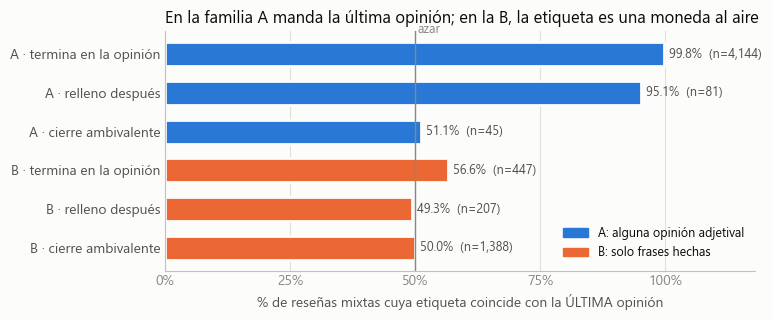

In [23]:
d = (F[F.familia.isin([FAM_A, FAM_B])].groupby(['familia', 'final'])
     .agg(tasa=('gana_ultima', 'mean'), n=('gana_ultima', 'size')).reset_index())
d['orden_final'] = d.final.map({'opinion': 0, 'relleno': 1, 'cierre': 2})
d = d.sort_values(['familia', 'orden_final'], ascending=[False, False])
NOMBRE_FINAL = {'opinion': 'termina en la opinión', 'relleno': 'relleno después', 'cierre': 'cierre ambivalente'}
COLOR_FAMILIA = {FAM_A: AZUL, FAM_B: NARANJA}

fig, ax = plt.subplots(figsize=(7.8, 3.3))
ax.barh(np.arange(len(d)), 100 * d.tasa, height=0.62, color=[COLOR_FAMILIA[f] for f in d.familia],
        edgecolor=SUPERFICIE, linewidth=2)
for yy, (v, n) in enumerate(zip(d.tasa, d.n)):
    ax.text(100 * v + 1, yy, f'{100 * v:.1f}%  (n={n:,})', va='center', fontsize=9, color=TINTA2)
ax.set_yticks(np.arange(len(d)), [('A · ' if f == FAM_A else 'B · ') + NOMBRE_FINAL[fi] for f, fi in zip(d.familia, d.final)])
ax.axvline(50, color=TENUE, linewidth=1)
ax.text(50.5, len(d) - 0.45, 'azar', color=TENUE, fontsize=9)
ax.set_xlim(0, 118); ax.set_xticks([0, 25, 50, 75, 100], ['0%', '25%', '50%', '75%', '100%'])
ax.xaxis.grid(True); ax.set_axisbelow(True); ax.tick_params(length=0)
ax.set_xlabel('% de reseñas mixtas cuya etiqueta coincide con la ÚLTIMA opinión')
ax.set_title('En la familia A manda la última opinión; en la B, la etiqueta es una moneda al aire', color=TINTA)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in COLOR_FAMILIA.values()],
          labels=['A: alguna opinión adjetival', 'B: solo frases hechas'], loc='lower right', frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

In [24]:
# Dos ejemplos tal como los ve el parser
def mostrar_analisis(i):
    a = ANALISIS[i]
    print(f'[{y[i]}]  {X[i]}')
    for o in a['opiniones']:
        fam = 'A' if es_adjetival(o) else 'B'
        print(f"    opinión {fam} {polaridad_semantica(o['clave']):+d}  {o['nucleo']!r:44s} "
              f"conector: {o['conector'] or '-'} ({o['tipo_conector']})")
    final, relleno = tipo_de_final(a)
    print(f"    termina en: {final}" + (f" ({a['cierre'] or a['cierre_en_linea']})" if final == 'cierre' else '') + '\n')

mostrar_analisis(F[(F.familia == FAM_A) & (F.conector == 'aditivo') & (F.final == 'opinion')].index[0])
mostrar_analisis(F[(F.familia == FAM_B) & (F.final == 'cierre')].index[0])

[positivo]  Comparto mi experiencia con este aparato que lo compre a mediados de mes y llego en tres dias a mi casa. La verdad sea dicha, el boton de encendido me parecio incomodo en el uso real, lo he estado usando en la oficina todas las tardes. Aun asi, tuve que escribirles un par de veces por una duda de configuracion y el soporte tecnico se sintio funcional al final de cuentas.
    opinión A -1  'me parecio incomodo'                        conector: - (ninguno)
    opinión A +1  'se sintio funcional'                        conector: y (aditivo)
    termina en: opinion

[negativo]  La compré a mediados de año por internet y tardó como una semana en llegar a mi casa, nada fuera de lo normal. La uso todos los días en el celular que llevo al trabajo. La funda fue un error de compra y el botón de encendido vale totalmente la pena. Mi hermano me dijo que él habría elegido otro modelo, pero eso ya es cosa de cada quien. Lo dejo a tu criterio.
    opinión B -1  'fue un error'             

In [25]:
# Techo aproximado: en cada celda (familia B x final) lo mejor que puede hacer una regla es max(p, 1 - p)
B_mix = F[F.familia == FAM_B]
aciertos_max_B = B_mix.groupby('final').gana_ultima.agg(lambda s: len(s) * max(s.mean(), 1 - s.mean())).sum()
errores_min_B = len(B_mix) - aciertos_max_B
techo = 1 - errores_min_B / len(y)
print(f'Mixtas B: {len(B_mix):,} reseñas ({100 * len(B_mix) / len(y):.1f} % del train). '
      f'Aun acertando todo lo demás, cuestan ≥ {errores_min_B:.0f} errores -> techo ≈ {techo:.3f}')

Mixtas B: 2,042 reseñas (17.0 % del train). Aun acertando todo lo demás, cuestan ≥ 990 errores -> techo ≈ 0.917


**Lo que muestran las tablas**
- **Mixtas A.** Si la reseña mezcla opiniones de signo contrario y al menos una es adjetival, la etiqueta es la de la **última opinión** en el 99.8 % de las que terminan en opinión (n = 4 144), y eso vale **con cualquier conector**: 99.6-100 % también con *"y"*, *"además"*, *"por otro lado"* o sin conector (tabla cruzada). Con relleno detrás de la última opinión sigue mandando (95 %); solo las pocas que cierran con una frase ambivalente (n = 45) caen al azar. El aparente azar de los conectores aditivos de la sección 5 se debía a que allí se mezclaban las dos familias.
- **Mixtas B.** Si todas las opiniones son frases hechas, la última opinión gana solo el 51.4 % de las veces (n = 2 042, el 17.0 % del train) y v1 acierta el 53.1 %. En experimentos exploratorios probamos orden, posición, aspecto, intensidad, identidad del cierre, mayoría de opiniones y TF-IDF dentro del subconjunto (LR, árbol y HGB, con pruebas de permutación): todo queda entre 47 % y 53 %, sin significación (sección 16). **Es ruido de etiqueta.** Solo quedan señales débiles y en pocos casos: si la reseña B termina en una opinión, la última gana algo más a menudo (56.6 %), y más aún si la introduce un conector fuerte (81 %, pero n = 27).
- **Techo.** Aunque todo lo demás se acertara, la mejor regla por celda en las mixtas B deja unos 990 errores: el techo práctico de accuracy en validación cruzada ronda **0.9175**, es decir, 0.915–0.92 (no es una cota estricta: un modelo puede exprimir algo las señales débiles, y también sobreajustar ruido).
- **Margen recuperable.** v1 todavía comete 160 errores fuera de las mixtas B, la mayoría en celdas **deterministas**: reseñas coherentes (una opinión o todas del mismo signo) seguidas de relleno o de un cierre, mixtas A que terminan en opinión o con relleno, neutrales. Los dos componentes nuevos atacan exactamente eso.

## 10. Componente nuevo 1: `estructural` (parser de plantillas → rasgos firmados → HistGradientBoosting)

**Qué hace.** Transforma cada reseña en **59 rasgos numéricos** que describen su estructura según el parser de la sección 9, y los clasifica con un `HistGradientBoostingClassifier`:
- signo de la primera y de la última opinión, de la última opinión adjetival y de la última frase hecha;
- si la reseña es coherente o mixta y, en las mixtas, el signo de la última opinión separado por familia (`signo_mixta_A`, `signo_mixta_B`), por tipo de conector del último cambio de signo y por conector concreto;
- cómo termina la reseña (opinión, relleno o cierre ambivalente), cruzado con el signo de la última opinión;
- conteos de opiniones positivas, negativas, adjetivales y fijas, y número de oraciones.

Los rasgos están **firmados**: valen +1 o −1 según la polaridad de la opinión implicada. Así el árbol aprende reglas generales como *"mixta A → manda la última"* o *"una sola opinión seguida de relleno → su signo"* sin memorizar cada adjetivo.

**Por qué funciona.** La bolsa de palabras ve las palabras, pero no sabe cuál es la última opinión ni a qué familia pertenece; el parser lo hace explícito y el HGB combina esas señales de forma no lineal (familia × final × conector). Corrige sobre todo celdas deterministas donde v1 fallaba.

**Cómo se evita la fuga.** Todo lo que se aprende de los datos ocurre en `fit`, es decir, solo con el fold de entrenamiento:
1. el **vocabulario del corrector de typos** (frecuencias de las palabras de los textos de entrenamiento);
2. la **polaridad de cada clave de opinión** (`modo_polaridad='aprendida'`): la etiqueta mayoritaria de las reseñas de entrenamiento que tienen esa única opinión; con menos de 3 apariciones se usa la polaridad semántica del inventario. En la práctica es un **léxico manual que la mayoría de etiquetas del fold confirma**: en los 10 folds de las dos particiones coincide con la polaridad semántica en todas las claves (sección 13.2);
3. el **HistGradientBoosting** (`learning_rate=0.05`, 200 iteraciones, 15 hojas, `min_samples_leaf=20`; sin *early stopping*, para que el CV y el ajuste final se comporten igual).

El inventario de regex es fijo y no se ajusta a etiquetas, pero lo escribimos a mano mirando reseñas de train: es un sesgo de diseño que discutimos en las limitaciones. (En el experimento original, la versión con polaridad semántica fija, que no usa ninguna etiqueta, dio exactamente el mismo resultado.)

El componente es un `Pipeline` de scikit-learn que recibe **texto crudo**, así que funciona dentro de `cross_val_predict` y de `VotingClassifier` (que le pasan las etiquetas codificadas 0/1/2; `RasgosPlantilla` acepta ambos formatos).

In [26]:
CONECTORES_RASGO = ['eso si', 'aun asi', 'al final', 'con todo', 'pero', 'a fin de cuentas', 'por otro lado', 'de paso',
                    'por cierto', 'ademas', 'ahora', 'y', '', 'lo que si', 'aunque', 'sin embargo', 'pero al final',
                    'igual', 'en cambio', 'ahora bien', 'aun con eso']


def rasgos_plantilla(analisis, signo=polaridad_semantica):
    """59 rasgos de una reseña, casi todos «firmados»: valen +1 o -1 según la polaridad de la opinión implicada."""
    ops, S, f = analisis['opiniones'], analisis['oraciones'], {}
    n = len(ops)
    signos = [signo(o['clave']) for o in ops]
    f['sin_opinion'] = float(n == 0)
    f['n_opiniones'] = n
    f['n_positivas'] = sum(s == 1 for s in signos)
    f['n_negativas'] = sum(s == -1 for s in signos)
    f['n_adjetivales'] = sum(es_adjetival(o) for o in ops)
    f['n_fijas'] = n - f['n_adjetivales']
    f['signo_mayoria'] = float(np.sign(f['n_positivas'] - f['n_negativas']))
    s_primera = signos[0] if n else 0
    s_ultima = signos[-1] if n else 0
    f['signo_primera'] = s_primera
    f['signo_ultima'] = s_ultima
    coherente = n > 0 and len(set(signos)) == 1
    mixta = len(set(signos)) == 2
    f['coherente'] = float(coherente)
    f['signo_coherente'] = s_ultima if coherente else 0
    f['mixta'] = float(mixta)
    adj = [s for s, o in zip(signos, ops) if es_adjetival(o)]
    fij = [s for s, o in zip(signos, ops) if not es_adjetival(o)]
    f['signo_ultima_adj'] = adj[-1] if adj else 0
    f['signo_primera_adj'] = adj[0] if adj else 0
    f['signo_ultima_fija'] = fij[-1] if fij else 0
    f['signo_mixta_A'] = s_ultima if (mixta and adj) else 0          # mixta con algún adjetivo: manda la última
    f['signo_mixta_B'] = s_ultima if (mixta and not adj) else 0      # mixta solo de frases hechas: ~azar
    # conector del último cambio de signo (o de la última opinión si no hay cambio)
    jc = [j for j in range(1, n) if signos[j] != signos[j - 1]][-1] if mixta else n - 1
    con = ops[jc]['conector'] if n else ''
    tipo = ops[jc]['tipo_conector'] if n else 'ninguno'
    for t in ['fuerte', 'debil', 'aditivo', 'ninguno']:
        f['conector_' + t] = float(tipo == t)
        f['signo_mixta_conector_' + t] = s_ultima if (tipo == t and mixta) else 0
    for c in CONECTORES_RASGO:
        f['signo_mixta_con=' + (c or 'nada')] = s_ultima if (con == c and mixta) else 0
    # cómo termina la reseña
    if n:
        ultima = ops[-1]
        final, relleno = tipo_de_final(analisis)
        f['relleno_despues'] = relleno
        f['cierre'] = float(bool(analisis['cierre']))
        f['cierre_en_linea'] = float(bool(analisis['cierre_en_linea']))
        f['termina_opinion'] = float(final == 'opinion')
        f['termina_relleno'] = float(final == 'relleno')
        f['termina_cierre'] = float(final == 'cierre')
        f['signo_ultima_x_termina_opinion'] = s_ultima * f['termina_opinion']
        f['signo_ultima_x_termina_relleno'] = s_ultima * f['termina_relleno']
        f['signo_ultima_x_termina_cierre'] = s_ultima * f['termina_cierre']
        f['posicion_ultima'] = ultima['oracion'] / max(1, len(S) - 1)
        cola = ultima['resto_fragmento'] + ' ' + ultima['despues']
        f['signo_ultima_eso_si_cola'] = s_ultima * float(bool(re.search(r'\beso si\b', cola)))
        f['signo_ultima_algun_fuerte'] = s_ultima * float(any(o['tipo_conector'] == 'fuerte' for o in ops[1:]))
    else:
        for k in ['relleno_despues', 'cierre', 'cierre_en_linea', 'termina_opinion', 'termina_relleno',
                  'termina_cierre', 'signo_ultima_x_termina_opinion', 'signo_ultima_x_termina_relleno',
                  'signo_ultima_x_termina_cierre', 'posicion_ultima', 'signo_ultima_eso_si_cola',
                  'signo_ultima_algun_fuerte']:
            f[k] = 0.0
    f['n_oraciones'] = len(S)
    return f


def _es_positivo(v):   # acepta etiquetas de texto o codificadas (0 = negativo, 1 = neutral, 2 = positivo)
    return v == 'positivo' or (not isinstance(v, str) and int(v) == 2)


def _es_negativo(v):
    return v == 'negativo' or (not isinstance(v, str) and int(v) == 0)


class RasgosPlantilla(TransformerMixin, BaseEstimator):
    """Texto crudo -> DataFrame de rasgos estructurales. En fit() se ajustan, solo con los textos de entrenamiento,
    el corrector de typos y (modo_polaridad='aprendida') la polaridad de cada clave de opinión: la etiqueta
    mayoritaria de las reseñas de entrenamiento que tienen esa única opinión (con < min_n apariciones se usa la
    polaridad semántica del inventario)."""

    def __init__(self, min_frec=5, modo_polaridad='aprendida', min_n=3):
        self.min_frec = min_frec
        self.modo_polaridad = modo_polaridad
        self.min_n = min_n

    def _ajustar(self, X, y):
        self.corrector_ = CorrectorTypos(self.min_frec).fit([normalizar(t) for t in X])
        self.lexico_ = {}
        analisis = self.analizar(X)
        if self.modo_polaridad == 'aprendida':
            conteo = {}
            for a, v in zip(analisis, y):
                if len(a['opiniones']) != 1 or not (_es_positivo(v) or _es_negativo(v)):
                    continue
                conteo.setdefault(a['opiniones'][0]['clave'], [0, 0])[int(_es_positivo(v))] += 1
            self.lexico_ = {k: (1 if pos > neg else -1) for k, (neg, pos) in conteo.items() if neg + pos >= self.min_n}
        return analisis

    def fit(self, X, y=None):
        self._ajustar(X, y)
        return self

    def fit_transform(self, X, y=None):
        return self._tabla(self._ajustar(X, y))      # analiza el train una sola vez

    def signo(self, clave):
        return self.lexico_.get(clave, polaridad_semantica(clave))

    def analizar(self, X):
        return [analizar_resena(self.corrector_.transform(normalizar(t))) for t in X]

    def _tabla(self, analisis):
        return pd.DataFrame([rasgos_plantilla(a, self.signo) for a in analisis]).astype(float)

    def transform(self, X):
        return self._tabla(self.analizar(X))


def modelo_estructural():
    return Pipeline([('rasgos', RasgosPlantilla(modo_polaridad='aprendida')),
                     ('clf', HistGradientBoostingClassifier(learning_rate=0.05, max_iter=200, max_leaf_nodes=15,
                                                            min_samples_leaf=20, early_stopping=False,
                                                            random_state=0))])


print(f'{len(rasgos_plantilla(demo))} rasgos por reseña. El componente:')
print(modelo_estructural())

59 rasgos por reseña. El componente:
Pipeline(steps=[('rasgos', RasgosPlantilla()),
                ('clf',
                 HistGradientBoostingClassifier(early_stopping=False,
                                                learning_rate=0.05,
                                                max_iter=200, max_leaf_nodes=15,
                                                random_state=0))])


In [27]:
# Los 59 rasgos de los dos ejemplos anteriores (polaridad semántica, solo para ilustrar)
ejemplos = [F[(F.familia == FAM_A) & (F.conector == 'aditivo') & (F.final == 'opinion')].index[0],
            F[(F.familia == FAM_B) & (F.final == 'cierre')].index[0]]
R = pd.DataFrame([rasgos_plantilla(ANALISIS[i]) for i in ejemplos], index=['ejemplo A', 'ejemplo B']).T + 0.0
print('Rasgos distintos de cero (de 59):')
R[(R != 0).any(axis=1)].round(2)

Rasgos distintos de cero (de 59):


,ejemplo A,ejemplo B
n_opiniones,2.0,2.0
n_positivas,1.0,1.0
n_negativas,1.0,1.0
n_adjetivales,2.0,0.0
n_fijas,0.0,2.0
signo_primera,-1.0,-1.0
signo_ultima,1.0,1.0
mixta,1.0,1.0
signo_ultima_adj,1.0,0.0
signo_primera_adj,-1.0,0.0


In [28]:
t0 = time.time()
OOF['estructural'] = cross_val_predict(modelo_estructural(), X, y, cv=CV, method='predict_proba', n_jobs=N_JOBS)
SEGUNDOS['estructural'] = time.time() - t0
print(f"estructural: accuracy OOF = {acc_oof(OOF['estructural']):.4f}  ({SEGUNDOS['estructural']:.0f} s)")
print(f"Experimento original (mismo código y partición): 0.9075 -> diferencia {acc_oof(OOF['estructural']) - 0.9075:+.4f}")

estructural: accuracy OOF = 0.9075  (25 s)
Experimento original (mismo código y partición): 0.9075 -> diferencia +0.0000


## 11. Componente nuevo 2: `est_lr` (polaridad por fragmento con supervisión débil → 80 rasgos → regresión logística)

**Qué hace.**
1. **Segmenta** cada reseña en fragmentos (oraciones; comas; *"y el/la…"*; *pero*; *aunque*) y anota el conector que abre cada fragmento: fuerte, *eso sí*, débil, aditivo, *y* o ninguno.
2. Un **clasificador de fragmentos** (regresión logística sobre TF-IDF de palabras 1-3 y caracteres `char_wb` 2-5) asigna a cada fragmento una de 6 clases: sin opinión, cierre ambivalente, A+, A−, F+, F− (F = frase hecha, la familia B). No hay etiquetas por fragmento, así que se entrena con **supervisión débil**:
   - **polaridad A**: una LR auxiliar aprende la polaridad de los adjetivos con los fragmentos que abre un conector **fuerte**, porque ahí la etiqueta de la reseña es la de ese fragmento ~99 % de las veces;
   - **frases hechas y cierres ambivalentes**: léxico escrito a mano con su polaridad semántica (no se ajusta a etiquetas);
   - **sin opinión**: todos los fragmentos de reseñas neutrales.
3. Con las probabilidades de los fragmentos calcula **80 rasgos por reseña**: secuencia de polaridades y familias, conector que introduce la primera, la penúltima y la última opinión, qué viene después de la última, cierre ambivalente, la regla del generador (sin opinión → neutral; coherente → su signo; mixta → la última) y P(neutral) de una LR a nivel de documento.
4. Un **meta-modelo** `StandardScaler + LogisticRegression(C=1)` produce P(negativo, neutral, positivo).

**Por qué funciona.** Generaliza el parser: el clasificador de fragmentos reconoce variantes y typos que las regex no cubren (gracias a los n-gramas de caracteres) y entrega probabilidades en lugar de decisiones duras; la LR final pondera las señales de forma calibrada. Es el mejor componente individual.

**Cómo se evita la fuga (cross-fitting).** Si el meta-modelo se entrenara con probabilidades de fragmento producidas por un clasificador que ya vio esas mismas reseñas, aprendería con señales demasiado limpias y fallaría con reseñas nuevas. Por eso `ComponenteEstLR.fit(X, y)` hace internamente un **cross-fitting de 5 folds**: las probabilidades de cada reseña de entrenamiento salen de un clasificador de fragmentos entrenado con los otros 4/5 del entrenamiento. Después reentrena el clasificador de fragmentos y la LR de P(neutral) con todo el entrenamiento: son los que usa `predict_proba` con reseñas nuevas. El fold de validación externo no participa en nada.

**Semilla interna.** La partición interna del cross-fitting usa `semilla_interna`. Para reproducir exactamente el experimento original, al calcular las OOF usamos `semilla_interna = 1000 + k` en el fold externo `k`; por eso usamos `oof_por_fold` (sección 8), que hace lo mismo que `cross_val_predict` (incluido pasar las etiquetas codificadas 0/1/2) pero permite que el modelo dependa del número de fold. El modelo final usa `semilla_interna = 1000`.

In [29]:
# ---------------------------------------------------------------- 1. segmentación en fragmentos + conector
FR_FUERTES = ['pero al final', 'pero', 'aun asi', 'aun con eso', 'con todo', 'al final de cuentas', 'al final',
              'a fin de cuentas', 'sin embargo', 'no obstante', 'de todos modos', 'de todas formas', 'lo que si',
              'ahora bien', 'aunque', 'mas alla de eso', 'a pesar de eso', 'a pesar de todo', 'pese a eso',
              'aun con todo', 'despues de todo']
FR_DEBILES = ['igual', 'total', 'en fin', 'en cambio', 'mientras que']
# Marcadores sin contenido que pueden preceder al conector ('la verdad, ...', 'para ser sincero, ...')
FR_MARCADORES = ['la verdad sea dicha', 'la verdad es que', 'la verdad', 'a decir verdad', 'para ser sincero',
                 'para ser sincera', 'para ser honesto', 'para ser honesta', 'siendo honesto', 'siendo sincero',
                 'he de decir que', 'lo cierto es que', 'para mi gusto', 'para mi', 'en mi opinion',
                 'en mi experiencia', 'sinceramente', 'honestamente', 'pues', 'bueno', 'ahora', 'o sea', 'la neta',
                 'asi que', 'entonces']
FR_TIPO = {}
for _c in FR_FUERTES: FR_TIPO[_c] = 'fuerte'
FR_TIPO['eso si'] = 'eso_si'
for _c in FR_DEBILES: FR_TIPO[_c] = 'debil'
for _c in ['por otro lado', 'por otra parte']: FR_TIPO[_c] = 'por_otro_lado'
for _c in ['ademas', 'tambien', 'encima', 'aparte', 'otra cosa', 'en cuanto a']: FR_TIPO[_c] = 'ademas'
for _c in ['de paso', 'por cierto']: FR_TIPO[_c] = 'de_paso'
FR_TIPO['y'] = 'y'
FR_TIPOS_CONECTOR = ['ninguno', 'fuerte', 'eso_si', 'debil', 'por_otro_lado', 'ademas', 'de_paso', 'y']
RE_FR_CONECTOR = re.compile(r'^(?:' + '|'.join(re.escape(c) for c in sorted(FR_TIPO, key=len, reverse=True)) + r')\b')
RE_FR_MARCADOR = re.compile(r'^(?:' + '|'.join(re.escape(c) for c in sorted(FR_MARCADORES, key=len, reverse=True))
                            + r')\b[\s,]*')
RE_FR_ORACION = re.compile(r'(?<=[.!?])\s+')
RE_FR_CORTE = re.compile(r'\s*[,;:]\s*|\s+(?=(?:y (?:el|la|los|las|me|eso|lo)|pero|aunque|mientras que)\b)')


def _solo_marcador(f):
    # True si el trozo es solo conector/marcador ('eso si', 'la verdad'): se pega al fragmento siguiente
    g = f
    for _ in range(3):
        m = RE_FR_CONECTOR.match(g) or RE_FR_MARCADOR.match(g)
        if not m:
            break
        g = g[m.end():].strip(' ,')
    return g.strip(' .!?') == ''


def conector_fragmento(f):
    # (tipo, conector) que abre el fragmento, saltando marcadores iniciales
    g = f
    for _ in range(4):
        m = RE_FR_CONECTOR.match(g)
        if m:
            return FR_TIPO[m.group(0)], m.group(0)
        m = RE_FR_MARCADOR.match(g)
        if not m or m.end() == 0:
            break
        g = g[m.end():].strip(' ,')
    return 'ninguno', ''


def segmentar(t):
    """Texto normalizado -> lista de fragmentos {texto, oracion, tipo_con, conector, ult_oracion}."""
    oraciones_t = [s for s in RE_FR_ORACION.split(t.strip()) if s.strip()] or ['']
    salida = []
    for si, s in enumerate(oraciones_t):
        partes = [p.strip() for p in RE_FR_CORTE.split(s) if p and p.strip()]
        frs, pendiente = [], ''
        for p in partes:
            if _solo_marcador(p):
                pendiente = (pendiente + ' ' + p).strip()
                continue
            frs.append((pendiente + ' ' + p).strip() if pendiente else p)
            pendiente = ''
        if pendiente:
            if frs:
                frs[-1] = frs[-1] + ' ' + pendiente
            else:
                frs.append(pendiente)
        for f in frs:
            tipo, con = conector_fragmento(f)
            salida.append(dict(texto=f, oracion=si, tipo_con=tipo, conector=con,
                               ult_oracion=(si == len(oraciones_t) - 1)))
    return salida


# ---------------------------------------------------------------- 2. léxico escrito a mano (polaridad semántica)
FRASES_POSITIVAS = [
    r'supero (?:todas )?mis expectativas', r'cumple de sobra', r'vale (?:totalmente )?la pena', r'valio la pena',
    r'(?:fue )?todo un acierto', r'me hizo la vida mas facil', r'tal como esperaba', r'tal cual lo esperaba',
    r'me sorprendio para bien', r'de maravilla', r'ni una sola queja', r'sin pensarlo', r'cinco estrellas',
    r'por encima de la media', r'justo lo que (?:estaba buscando|buscaba|necesitaba)',
    r'(?:termine|estoy|quede|quedo|quedamos|ando) (?:muy |bien )?feliz', r'me encant[oa]', r'con los ojos cerrados',
    r'me alegra haber (?:elegido|comprado)', r'(?:quede|estoy|quedo|dejo|dejó|ando) (?:muy )?encantad[oa]',
    r'(?<!no )(?<!no le )me gust[oa]\b', r'no me quejo', r'mejor de lo que (?:me )?imagina', r'mucho mejor de lo que',
    r'(?<!no )(?<!no se )(?:lo|la) recomiendo',
    r'(?<!no )(?<!no le )(?<!no les )(?<!no te )recomiendo (?:el|la|los|las|este|esta)\b',
    r'una maravilla', r'un exito', r'me tiene (?:muy )?content[oa]', r'(?:quede|estoy|quedo|ando) (?:muy )?content[oa]',
    r'nada mal', r'no esta (?:nada )?mal', r'me respondieron (?:muy )?rapido',
    r'(?<!no )(?<!no lo )(?<!no la )volveria a comprar', r'no (?:me )?(?:dio|da|ha dado) (?:ningun )?problema',
    r'excelente compra', r'buena compra', r'gran compra',
]
FRASES_NEGATIVAS = [
    r'defraudo (?:todas )?mis expectativas', r'se queda (?:muy |bastante )?cort[oa]', r'no vale lo que cuesta',
    r'(?:fue )?un error de compra', r'dolor de cabeza', r'me decepciono',
    r'funciona (?:bastante |muy )?mal\b', r'no (?:lo |la |los |las )?volveria a comprar', r'ni regalad[oa]',
    r'una (?:sola )?estrella', r'por debajo de la media', r'no es (?:para nada )?lo que esperaba',
    r'(?:quede|estoy|termine|ando) (?:muy )?molest[oa]', r'arrepentid[oa]', r'me arrepiento', r'tire el dinero',
    r'no pare de tener problemas', r'(?:termine|estoy|quede) harto',
    r'no (?:se )?(?:lo|la|los|las|le|les) recomiendo', r'no me gusto', r'no me gustaron', r'no me convenc',
    r'no me termin[oa] de convencer', r'peor compra', r'dinero tirado', r'perdida de dinero',
    r'deja (?:mucho )?que desear', r'no sirve', r'se (?:me )?dano', r'(?<!no )(?<!no me )(?:me )?(?:dio|da) problemas',
    r'fuente (?:continua )?de problemas', r'nunca (?:me )?funciono', r'no funciona', r'esperaba (?:otra cosa|mas)\b',
    r'se rompio', r'dejo de funcionar', r'me fallo', r'un desastre', r'una decepcion', r'decepcion total',
]
AMBIVALENTES = [
    r'cada quien', r'para gustos', r'sigo con dudas', r'ni fu ni fa', r'criterio', r'sopesa', r'no sabria (?:bien )?que',
    r'ni lo mejor ni lo peor', r'ni tan bueno ni tan malo', r'ahi lo dejo', r'no me decido', r'todavia no me decido',
    r'sentimientos encontrados', r'no me termin[oa] de decidir', r'no se (?:bien )?que pensar', r'sigo pensando',
    r'sigo dudando', r'cuento mi experiencia', r'cada cosa por su lado', r'hay de todo', r'ahi queda', r'ahi me quede',
    r'no se si termino', r'es lo que hay', r'me quedo con la duda', r'no se si recomendar', r'que cada uno',
    r'saque sus conclusiones', r'sacara sus conclusiones', r'ni bueno ni malo', r'ni muy bueno ni muy malo',
    r'tiene sus pros y sus contras', r'pros y contras', r'no se si (?:lo|la) recomendaria', r'juzgue',
]
RE_FRASES_POS = [re.compile(r'\b' + p) for p in FRASES_POSITIVAS]
RE_FRASES_NEG = [re.compile(r'\b' + p) for p in FRASES_NEGATIVAS]
RE_AMBIVALENTE = re.compile(r'\b(?:' + '|'.join(AMBIVALENTES) + r')')
RE_COPULA = re.compile(r'\b(?:se (?:ve|vio|veia|siente|sintio|sentia|mantuvo|mantiene|nota|noto)|resulto|resulta|salio|'
                       r'sale|parecio|parece|quedo|queda|termino siendo|es|fue|esta|estuvo|luce|lucia|era|me dejo)\b')


def contar_frases(t):
    return sum(1 for r in RE_FRASES_POS if r.search(t)), sum(1 for r in RE_FRASES_NEG if r.search(t))


# Ejemplo de segmentación
for d in segmentar(normalizar(X[ejemplos[0]])):
    print(f"  [{d['tipo_con']:>13s}] {d['texto']}")

  [      ninguno] comparto mi experiencia con este aparato que lo compre a mediados de mes y llego en tres dias a mi casa.
  [      ninguno] la verdad sea dicha el boton de encendido me parecio incomodo en el uso real
  [      ninguno] lo he estado usando en la oficina todas las tardes.
  [       fuerte] aun asi tuve que escribirles un par de veces por una duda de configuracion
  [            y] y el soporte tecnico se sintio funcional al final de cuentas.


In [30]:
# ---------------------------------------------------------------- 3. clasificador de fragmentos (6 clases)
CLASES_FRAGMENTO = ['sin_op', 'amb', 'A+', 'A-', 'F+', 'F-']   # sin opinión, cierre ambivalente, plantilla A/B ±


def a_texto(y):
    # Etiquetas de texto aunque lleguen codificadas 0/1/2 (cross_val_predict y VotingClassifier las codifican)
    y = np.asarray(y)
    return CLASES[y] if y.dtype.kind in 'iu' else y.astype(str)


class VectorizadorFragmentos:
    # TF-IDF de palabras (1-3) + caracteres char_wb (2-5): los n-gramas de caracteres absorben los typos
    def __init__(self, char=True, ngramas=(1, 3)):
        self.char, self.ngramas = char, ngramas

    def fit(self, F):
        self.palabras = TfidfVectorizer(ngram_range=self.ngramas, sublinear_tf=True, min_df=2, dtype=np.float32).fit(F)
        if self.char:
            self.caracteres = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), sublinear_tf=True, min_df=3,
                                              dtype=np.float32).fit(F)
        return self

    def transform(self, F):
        A = self.palabras.transform(F)
        if self.char:
            A = hstack([A, self.caracteres.transform(F)]).tocsr()
        return A


class ClasificadorFragmentos:
    """Supervisión débil, todo con las reseñas de entrenamiento:
    - polaridad de la plantilla A: LR sobre los fragmentos que abre un conector FUERTE (ahí la etiqueta de la
      reseña es la de esa opinión ~99 % de las veces) -> puntaje g; un fragmento con verbo copulativo y |g| > 1
      se etiqueta A+ / A-;
    - frases hechas (F±) y cierres ambivalentes: léxico escrito a mano (polaridad semántica, no etiquetas);
    - 'sin_op': todos los fragmentos de reseñas neutrales;
    y con esas etiquetas débiles entrena una LR multiclase de palabras + caracteres que generaliza a variantes."""

    def __init__(self, C=10.0, C_adjetivo=3.0, umbral_adjetivo=1.0, char=True, incluir_polares_sin_op=False):
        self.C, self.C_adjetivo, self.umbral_adjetivo = C, C_adjetivo, umbral_adjetivo
        self.char, self.incluir_polares_sin_op = char, incluir_polares_sin_op

    def puntaje_adjetivo(self, F):
        return self.lr_adjetivo.decision_function(self.vec_adjetivo.transform(F))

    def etiquetar(self, F, g=None):
        if g is None:
            g = self.puntaje_adjetivo(F)
        salida = []
        for t, gi in zip(F, g):
            if RE_AMBIVALENTE.search(t):
                salida.append('amb'); continue
            p, n = contar_frases(t)
            if p or n:
                salida.append('F+' if p > n else ('F-' if n > p else '?')); continue
            if abs(gi) > self.umbral_adjetivo and RE_COPULA.search(t):
                salida.append('A+' if gi > 0 else 'A-'); continue
            salida.append('sin_op')
        return salida

    def fit(self, segmentos, y):
        etiquetas = a_texto(y)
        # (a) polaridad de adjetivos aprendida con los fragmentos introducidos por un conector fuerte
        FA, yA = [], []
        for s, l in zip(segmentos, etiquetas):
            if l == 'neutral':
                continue
            for d in s:
                if d['tipo_con'] == 'fuerte' and not RE_AMBIVALENTE.search(d['texto']):
                    FA.append(d['texto']); yA.append(l == 'positivo')
        self.vec_adjetivo = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2).fit(FA)
        self.lr_adjetivo = LogisticRegression(C=self.C_adjetivo, max_iter=3000).fit(self.vec_adjetivo.transform(FA), yA)
        # (b) etiquetas débiles de todos los fragmentos
        F, z, polar_sin_op = [], [], []
        todos = [d['texto'] for s in segmentos for d in s]
        etiqueta_resena = np.repeat([l for l in etiquetas], [len(s) for s in segmentos])
        for t, l, e in zip(todos, etiqueta_resena, self.etiquetar(todos)):
            if l == 'neutral':
                e = 'sin_op'
            elif e == '?':
                continue
            F.append(t); z.append(CLASES_FRAGMENTO.index(e)); polar_sin_op.append(l != 'neutral' and e == 'sin_op')
        z, polar_sin_op = np.array(z), np.array(polar_sin_op)
        # (c) LR multiclase; los fragmentos 'sin_op' de reseñas polares son dudosos y no se usan para entrenar
        self.vec = VectorizadorFragmentos(self.char).fit(F)
        Xf = self.vec.transform(F)
        m = np.ones(len(z), bool) if self.incluir_polares_sin_op else ~polar_sin_op
        self.clf = LogisticRegression(C=self.C, max_iter=3000).fit(Xf[m], z[m])
        return self

    def predecir_fragmentos(self, F):
        P = np.zeros((len(F), len(CLASES_FRAGMENTO)))
        P[:, self.clf.classes_] = self.clf.predict_proba(self.vec.transform(F))
        return P

    def predecir_resenas(self, segmentos):
        # Para cada reseña: (probabilidades de sus fragmentos, puntaje de adjetivo de cada fragmento)
        F = [d['texto'] for s in segmentos for d in s]
        P, g = self.predecir_fragmentos(F), self.puntaje_adjetivo(F)
        salida, k = [], 0
        for s in segmentos:
            salida.append((P[k:k + len(s)], g[k:k + len(s)]))
            k += len(s)
        return salida


def modelo_neutral():
    # P(neutral) a nivel de reseña: TF-IDF de palabras + LR binaria (neutral frente a polar)
    return make_pipeline(TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2),
                         LogisticRegression(C=5, max_iter=5000))


print('Clases de fragmento:', CLASES_FRAGMENTO)
print('Modelo de P(neutral):', modelo_neutral())

Clases de fragmento: ['sin_op', 'amb', 'A+', 'A-', 'F+', 'F-']
Modelo de P(neutral): Pipeline(steps=[('tfidfvectorizer',
                 TfidfVectorizer(min_df=2, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('logisticregression', LogisticRegression(C=5, max_iter=5000))])


In [31]:
# ---------------------------------------------------------------- 4. rasgos por reseña y componente est_lr
N_TIPOS = len(FR_TIPOS_CONECTOR)
ADITIVOS_FR = ('por_otro_lado', 'ademas', 'de_paso')


def one_hot_conector(tipo):
    v = np.zeros(N_TIPOS)
    v[FR_TIPOS_CONECTOR.index(tipo)] = 1
    return v


def regla_estructural(arg, P):
    """Regla del generador sobre las clases de fragmento: sin opinión -> neutral; opiniones del mismo signo -> ese
    signo; mixta -> la última. Devuelve (predicción 0/1/2, categoría): 0 sin opinión, 1 una/coherentes A,
    2 una/coherentes F, 3 una/coherentes A y F, 4 mixta solo A, 5 mixta con alguna F."""
    ops = np.flatnonzero(arg >= 2)
    if len(ops) == 0:
        return 1, 0
    pos = np.isin(arg[ops], (2, 4))
    famA = np.isin(arg[ops], (2, 3))
    if pos.all() or (~pos).all():
        cat = 1 if famA.all() else (2 if (~famA).all() else 3)
        return (2 if pos[0] else 0), cat
    return (2 if pos[-1] else 0), (4 if famA.all() else 5)


def rasgos_fragmentos(seg, P, g, p_neutral):
    """~80 rasgos de una reseña a partir de las probabilidades de sus fragmentos."""
    P = np.asarray(P, dtype=float)
    arg = P.argmax(1)
    p_opinion = P[:, 2:].sum(1)
    s = (P[:, 2] + P[:, 4] - P[:, 3] - P[:, 5]) / np.maximum(p_opinion, 1e-6)    # polaridad en [-1, 1]
    fam_A = (P[:, 2] + P[:, 3]) / np.maximum(p_opinion, 1e-6)                   # 1 = plantilla A, 0 = frase F
    ops = np.flatnonzero(arg >= 2)
    nfr = len(seg)
    nsent = seg[-1]['oracion'] + 1 if seg else 1
    # conteos globales
    f = [p_neutral, nfr, nsent, len(ops), np.isin(arg, (2, 4)).sum(), np.isin(arg, (3, 5)).sum(),
         np.isin(arg, (2, 3)).sum(), np.isin(arg, (4, 5)).sum(), (arg == 2).sum(), (arg == 3).sum(), (arg == 4).sum(),
         (arg == 5).sum(), p_opinion.sum(), p_opinion.max() if nfr else 0, P[:, 1].max() if nfr else 0,
         P[-1, 1] if nfr else 0, (arg == 1).sum()]
    sg = np.sign(s[ops]) if len(ops) else np.array([])
    f += [s[ops].sum() if len(ops) else 0, s[ops].mean() if len(ops) else 0,
          float(len(ops) > 0 and (sg > 0).all() or len(ops) > 0 and (sg < 0).all()),
          float(len(ops) > 0 and (sg > 0).any() and (sg < 0).any())]
    # última opinión: polaridad, familia, conector que la introduce, qué viene después
    for j in ([ops[-1]] if len(ops) else [None]):
        if j is None:
            f += [0, 0, 0] + [0] * N_TIPOS + [0, 0, 0, 0]
        else:
            f += [s[j], fam_A[j], p_opinion[j]] + list(one_hot_conector(seg[j]['tipo_con'])) + [
                nfr - 1 - j, float(seg[j]['ult_oracion']), P[j + 1:, 1].max() if j + 1 < nfr else 0, g[j]]
    # primera opinión
    for j in ([ops[0]] if len(ops) else [None]):
        if j is None:
            f += [0, 0] + [0] * N_TIPOS + [0]
        else:
            f += [s[j], fam_A[j]] + list(one_hot_conector(seg[j]['tipo_con'])) + [nfr - 1 - j]
    # penúltima opinión
    for j in ([ops[-2]] if len(ops) >= 2 else [None]):
        if j is None:
            f += [0, 0] + [0] * N_TIPOS
        else:
            f += [s[j], fam_A[j]] + list(one_hot_conector(seg[j]['tipo_con']))
    # última opinión introducida por cada tipo de conector
    for tipos in [('fuerte',), ('eso_si',), ('debil',), ADITIVOS_FR, ('y',), ('ninguno',)]:
        jj = [j for j in ops if seg[j]['tipo_con'] in tipos]
        f += [s[jj[-1]] if jj else 0, float(bool(jj))]
    en_ultima_oracion = [j for j in ops if seg[j]['ult_oracion']]
    f += [s[en_ultima_oracion[-1]] if en_ultima_oracion else 0, float(bool(en_ultima_oracion))]
    pred, cat = regla_estructural(arg, P)
    f += [pred == 0, pred == 1, pred == 2] + [cat == c for c in range(6)]
    return np.array(f, dtype=np.float32)


def matriz_rasgos(segmentos, Ps, gs, p_neutrales):
    return np.vstack([rasgos_fragmentos(s, P, g, pn) for s, P, g, pn in zip(segmentos, Ps, gs, p_neutrales)])


class ComponenteEstLR(ClassifierMixin, BaseEstimator):
    """est_lr: texto crudo -> fragmentos -> ClasificadorFragmentos -> ~80 rasgos -> StandardScaler + LR.

    fit(X, y) hace el cross-fitting internamente: las probabilidades de fragmento de cada reseña de entrenamiento
    salen de un ClasificadorFragmentos entrenado con los otros (n_folds_internos - 1)/n_folds_internos del
    entrenamiento (partición interna con semilla_interna), de modo que el meta-modelo aprende con probabilidades
    tan 'honestas' como las que verá en reseñas nuevas. Después se reentrenan el clasificador de fragmentos y la LR
    de P(neutral) con todo el entrenamiento: son los que usa predict_proba."""

    def __init__(self, C=1.0, n_folds_internos=5, semilla_interna=1000):
        self.C = C
        self.n_folds_internos = n_folds_internos
        self.semilla_interna = semilla_interna

    @staticmethod
    def _preparar(X):
        textos = [normalizar(t) for t in X]
        return textos, [segmentar(t) for t in textos]

    def fit(self, X, y):
        y = np.asarray(y)
        textos, segs = self._preparar(X)
        n = len(segs)
        P_cf, g_cf, pn_cf = [None] * n, [None] * n, np.zeros(n)
        particion = StratifiedKFold(self.n_folds_internos, shuffle=True, random_state=self.semilla_interna)
        for tr, te in particion.split(np.zeros(n), y):
            frag = ClasificadorFragmentos().fit([segs[i] for i in tr], y[tr])
            for j, (P, g) in zip(te, frag.predecir_resenas([segs[i] for i in te])):
                P_cf[j], g_cf[j] = P.astype(np.float32), g.astype(np.float32)
            neutral = modelo_neutral().fit([textos[i] for i in tr], a_texto(y[tr]) == 'neutral')
            pn_cf[te] = neutral.predict_proba([textos[i] for i in te])[:, 1]
        self.fragmentos_ = ClasificadorFragmentos().fit(segs, y)
        self.neutral_ = modelo_neutral().fit(textos, a_texto(y) == 'neutral')
        self.meta_ = make_pipeline(StandardScaler(), LogisticRegression(C=self.C, max_iter=5000))
        self.meta_.fit(matriz_rasgos(segs, P_cf, g_cf, pn_cf), y)
        self.classes_ = self.meta_.classes_
        return self

    def rasgos(self, X):
        textos, segs = self._preparar(X)
        R = self.fragmentos_.predecir_resenas(segs)
        P = [p.astype(np.float32) for p, _ in R]
        g = [gi.astype(np.float32) for _, gi in R]
        return matriz_rasgos(segs, P, g, self.neutral_.predict_proba(textos)[:, 1])

    def predict_proba(self, X):
        return self.meta_.predict_proba(self.rasgos(X))

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(1)]


def modelo_est_lr(semilla_interna=1000):
    return ComponenteEstLR(C=1.0, n_folds_internos=5, semilla_interna=semilla_interna)


print('Parámetros del componente (clonable):', clone(modelo_est_lr()).get_params())

Parámetros del componente (clonable): {'C': 1.0, 'n_folds_internos': 5, 'semilla_interna': 1000}


In [32]:
t0 = time.time()
OOF['est_lr'] = oof_por_fold(lambda k: modelo_est_lr(semilla_interna=1000 + k), X, y, CV)
SEGUNDOS['est_lr'] = time.time() - t0
print(f"est_lr: accuracy OOF = {acc_oof(OOF['est_lr']):.4f}  ({SEGUNDOS['est_lr']:.0f} s)")
print(f"Experimento original (mismo código y partición): 0.9127 -> diferencia {acc_oof(OOF['est_lr']) - 0.9127:+.4f}")

est_lr: accuracy OOF = 0.9126  (331 s)
Experimento original (mismo código y partición): 0.9127 -> diferencia -0.0001


**Reproducibilidad.** Ambos componentes se portaron desde los scripts de los experimentos originales (renombrados y comentados en español, y empaquetados como estimadores). Con la partición 42 reproducen sus accuracies OOF: `estructural` 0.9075 (original 0.9075) y `est_lr` 0.9126 (original 0.9127). Las diferencias de accuracy son +0.0000 (estructural) y -0.0001 (est_lr), por debajo de 0.001. En una comprobación aparte, con los mismos hilos de BLAS que el experimento original (16 por proceso), las probabilidades OOF coinciden también exactamente (diferencia máxima 0). Con los 4 hilos fijos de este notebook, la regresión logística puede terminar en un punto ligeramente distinto y cambiar unas pocas predicciones de `est_lr` (de 12 000) sin alterar la accuracy de forma apreciable: es la razón para fijar los hilos.

## 12. Ensemble v3b: 6 componentes con pesos en rejilla
Mismo procedimiento que en la sección 8, ahora con los 6 componentes (los 4 de v1 + `estructural` + `est_lr`): rejilla de paso 0.1 sobre las OOF de la partición 42 ($\binom{15}{5} = 3003$ combinaciones que suman 1) y validación anidada de la selección de pesos con `StratifiedKFold(5, shuffle=True, random_state=123)`.

Para separar el aporte de cada componente nuevo comparamos cuatro variantes. La **prueba de McNemar** compara reseña a reseña los aciertos de cada variante frente a v1 sobre las mismas OOF: *gana* = reseñas que la variante acierta y v1 no, *pierde* = al revés; el p-valor es el de una binomial exacta de dos colas. Aquí los pesos de cada variante se eligen con todas las OOF, lo que favorece algo a las variantes con más componentes; la versión anidada, más estricta, está en la sección 13.1.

In [33]:
NOMBRES_V3B = NOMBRES_V1 + ['estructural', 'est_lr']
OOF_V3B = {n: OOF[n] for n in NOMBRES_V3B}
pesos_v3b, oof_v3b, W6, acc_W6 = mejores_pesos(OOF_V3B, y)
mejores = np.argsort(-acc_W6, kind='stable')[:10]
print(f'Combinaciones evaluadas: {len(W6)}. Las 10 mejores:')
display(pd.DataFrame(W6[mejores], columns=NOMBRES_V3B).assign(accuracy_oof=acc_W6[mejores].round(4)))

anidado_v3b = seleccion_anidada(OOF_V3B, y)
print('Validación anidada de la selección de pesos (5 partes):')
display(anidado_v3b.round(4))
pred_v3b = CLASES[prob_ensemble(OOF_V3B, pesos_v3b).argmax(1)]
print(f'Ensemble v3b: accuracy OOF {oof_v3b:.4f} | selección anidada {anidado_v3b.accuracy_parte_no_vista.mean():.4f}')
print('Pesos elegidos:', {n: w for n, w in pesos_v3b.items()})

Combinaciones evaluadas: 3003. Las 10 mejores:


,stacking,lr_palabras,lr_pal_car,svc_pal_car,estructural,est_lr,accuracy_oof
0,0.2,0.3,0.0,0.0,0.3,0.2,0.9180
1,0.2,0.3,0.0,0.0,0.2,0.3,0.9178
2,0.2,0.2,0.0,0.0,0.4,0.2,0.9177
3,0.1,0.3,0.0,0.0,0.4,0.2,0.9176
4,0.2,0.1,0.1,0.0,0.3,0.3,0.9175
5,0.2,0.1,0.2,0.0,0.3,0.2,0.9174
6,0.2,0.2,0.1,0.0,0.3,0.2,0.9174
7,0.2,0.2,0.0,0.0,0.3,0.3,0.9173
8,0.2,0.0,0.3,0.0,0.3,0.2,0.9171
9,0.2,0.3,0.0,0.0,0.4,0.1,0.9171


Validación anidada de la selección de pesos (5 partes):


,stacking,lr_palabras,lr_pal_car,svc_pal_car,estructural,est_lr,accuracy_parte_no_vista
0,0.2,0.3,0.0,0.0,0.2,0.3,0.9096
1,0.2,0.3,0.0,0.0,0.3,0.2,0.9233
2,0.2,0.3,0.0,0.0,0.3,0.2,0.9200
3,0.2,0.3,0.0,0.0,0.3,0.2,0.9212
4,0.2,0.1,0.1,0.0,0.3,0.3,0.9104


Ensemble v3b: accuracy OOF 0.9180 | selección anidada 0.9169
Pesos elegidos: {'stacking': 0.2, 'lr_palabras': 0.3, 'lr_pal_car': 0.0, 'svc_pal_car': 0.0, 'estructural': 0.3, 'est_lr': 0.2}


In [34]:
def comparar_variantes(P, pred_ref):
    variantes = {'v1 (4 componentes)': NOMBRES_V1,
                 'v1 + estructural': NOMBRES_V1 + ['estructural'],
                 'v1 + est_lr': NOMBRES_V1 + ['est_lr'],
                 'v3b = v1 + estructural + est_lr': NOMBRES_V3B}
    filas = []
    for nombre, comps in variantes.items():
        Pv = {n: P[n] for n in comps}
        pesos, acc, _, _ = mejores_pesos(Pv, y)
        anid = seleccion_anidada(Pv, y).accuracy_parte_no_vista.mean()
        mc = mcnemar(CLASES[prob_ensemble(Pv, pesos).argmax(1)], pred_ref, y)
        filas.append({'variante': nombre, 'accuracy_oof': acc, 'seleccion_anidada': anid,
                      'mcnemar_gana': mc['gana'], 'mcnemar_pierde': mc['pierde'], 'p_valor': mc['p'],
                      'pesos': ' · '.join(f'{n} {w:.1f}' for n, w in pesos.items() if w > 0)})
    return pd.DataFrame(filas).set_index('variante')

variantes_42 = comparar_variantes(OOF, pred_v1)
variantes_42.style.format({'accuracy_oof': '{:.4f}', 'seleccion_anidada': '{:.4f}', 'p_valor': '{:.1e}'})

,accuracy_oof,seleccion_anidada,mcnemar_gana,mcnemar_pierde,p_valor,pesos
variante,,,,,,
v1 (4 componentes),0.9069,0.9067,0,0,1.0e+00,stacking 0.5 · lr_palabras 0.4 · svc_pal_car 0.1
v1 + estructural,0.9152,0.9152,206,107,2.3e-08,stacking 0.3 · lr_palabras 0.3 · estructural 0.4
v1 + est_lr,0.9155,0.9117,251,148,2.8e-07,stacking 0.3 · lr_palabras 0.1 · lr_pal_car 0.2 · est_lr 0.4
v3b = v1 + estructural + est_lr,0.9180,0.9169,259,126,1.1e-11,stacking 0.2 · lr_palabras 0.3 · estructural 0.3 · est_lr 0.2


**Interpretación**
- La rejilla asigna a los dos componentes nuevos el 50 % del peso total: **stacking 0.2 · lr_palabras 0.3 · estructural 0.3 · est_lr 0.2**. `lr_pal_car` y `svc_pal_car` quedan con peso 0 porque su información ya la aportan `lr_palabras` y el stacking.
- La accuracy con selección anidada sube de 0.9067 a **0.9169** (**+1.02 pts**, unas 122 reseñas de cada 12 000). La diferencia entre OOF y anidada (0.9180 frente a 0.9169) es pequeña: los pesos casi no están sobreajustados. McNemar de v3b frente a v1: 259 reseñas ganadas frente a 126 perdidas (p = 1.1·10<sup>-11</sup>).
- Cada componente nuevo mejora a v1 por separado, y el estructural es el que más aporta. Juntos dan la mejor accuracy OOF, pero frente a *v1 + estructural* la ganancia de añadir `est_lr` es pequeña (0.9152 → 0.9169 con selección anidada) y, como se ve en la sección 13, no se repite con la partición 2024: los dos componentes capturan en buena parte la misma estructura de plantillas (en la sección 13.1 el aporte marginal de `est_lr` resulta prácticamente nulo).

## 13. Verificación con una segunda partición (`random_state=2024`) y robustez
Los pesos y casi todas las decisiones de diseño de los componentes se eligieron mirando la partición 42. Para comprobar que la mejora no es un artefacto de esa partición repetimos **todo** con otra: recalculamos las OOF de los 6 componentes con `StratifiedKFold(5, shuffle=True, random_state=2024)`, volvemos a elegir pesos con la rejilla y repetimos la validación anidada. Además aplicamos directamente a esas OOF los pesos elegidos con la partición 42. (Desactivable con `VERIFICAR_2024 = False`.)

Matiz: la variante final del componente `estructural` (inventario v2 + HistGradientBoosting) se eligió entre unas 9 variantes mirando la selección anidada de **las dos** particiones, así que para ese componente la partición 2024 es una verificación, no una prueba independiente.

In [35]:
if VERIFICAR_2024:
    CV_2024 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED_VERIFICACION)
    OOF_2024 = {}
    t0 = time.time()
    for nombre, fabrica in {**FABRICAS_V1, 'estructural': modelo_estructural}.items():
        OOF_2024[nombre] = cross_val_predict(fabrica(), X, y, cv=CV_2024, method='predict_proba', n_jobs=N_JOBS)
    OOF_2024['est_lr'] = oof_por_fold(lambda k: modelo_est_lr(semilla_interna=1000 + k), X, y, CV_2024)
    print(f'OOF de los 6 componentes con la partición 2024 en {time.time() - t0:.0f} s')
    display(pd.DataFrame({'partición 42': {n: acc_oof(OOF[n]) for n in NOMBRES_V3B},
                          'partición 2024': {n: acc_oof(OOF_2024[n]) for n in NOMBRES_V3B}}).round(4))

    pesos_v1_2024, _, _, _ = mejores_pesos({n: OOF_2024[n] for n in NOMBRES_V1}, y)
    pred_v1_2024 = CLASES[prob_ensemble({n: OOF_2024[n] for n in NOMBRES_V1}, pesos_v1_2024).argmax(1)]
    variantes_2024 = comparar_variantes(OOF_2024, pred_v1_2024)
    display(variantes_2024.style.format({'accuracy_oof': '{:.4f}', 'seleccion_anidada': '{:.4f}', 'p_valor': '{:.1e}'}))

    acc_pesos42_en_2024 = acc_oof(prob_ensemble(OOF_2024, pesos_v3b))
    acc_v1_enviado_2024 = acc_oof(prob_ensemble(OOF_2024, PESOS_ENVIADOS))
    print(f'Pesos de la partición 42 aplicados a las OOF 2024: v3b {acc_pesos42_en_2024:.4f} '
          f'| v1 con los pesos enviados {acc_v1_enviado_2024:.4f}')
else:
    print('Verificación con la partición 2024 desactivada (VERIFICAR_2024 = False).')

OOF de los 6 componentes con la partición 2024 en 767 s


,partición 42,partición 2024
stacking,0.9012,0.9004
lr_palabras,0.8951,0.8939
lr_pal_car,0.8981,0.8962
svc_pal_car,0.8998,0.8998
estructural,0.9075,0.9096
est_lr,0.9126,0.9116


,accuracy_oof,seleccion_anidada,mcnemar_gana,mcnemar_pierde,p_valor,pesos
variante,,,,,,
v1 (4 componentes),0.9076,0.9043,0,0,1.0e+00,stacking 0.4 · lr_pal_car 0.1 · svc_pal_car 0.5
v1 + estructural,0.9169,0.9163,237,125,4.1e-09,stacking 0.2 · lr_palabras 0.3 · svc_pal_car 0.1 · estructural 0.4
v1 + est_lr,0.9137,0.9096,284,211,1.2e-03,lr_palabras 0.1 · lr_pal_car 0.4 · est_lr 0.5
v3b = v1 + estructural + est_lr,0.9176,0.9145,321,201,1.7e-07,lr_palabras 0.3 · lr_pal_car 0.1 · estructural 0.4 · est_lr 0.2


Pesos de la partición 42 aplicados a las OOF 2024: v3b 0.9171 | v1 con los pesos enviados 0.9071


**Resultado de la verificación.** Con la partición 2024 la selección anidada pasa de 0.9043 (v1) a **0.9145** (v3b), **+1.02 pts**, con McNemar 321 / 201 (p = 1.7·10<sup>-7</sup>). La rejilla vuelve a dar a los componentes nuevos la mitad o más del peso (aquí el 60 %: lr_palabras 0.3 · lr_pal_car 0.1 · estructural 0.4 · est_lr 0.2), y los pesos elegidos con la partición 42 aplicados tal cual a las OOF 2024 dan 0.9171 frente a 0.9071 de v1 con sus pesos enviados. **La mejora de ~1 punto sobre v1 no depende de la partición.**

Lo que sí depende de la partición es el orden entre las variantes con componentes nuevos: con la 2024, *v1 + estructural* obtiene una selección anidada algo mayor que v3b (0.9163 frente a 0.9145), al revés que con la 42. Esa diferencia (±0.2 pts) está dentro del ruido de la selección de pesos y del ruido numérico descrito en la sección 8. La sección 13.1 lo mide con más semillas y con un McNemar anidado.

### 13.1 Robustez: más semillas de selección y aporte marginal de cada componente
Las cifras anteriores usan una sola semilla (123) para repartir las filas en la selección anidada, y el McNemar de la sección 12 compara predicciones con pesos elegidos con todas las OOF, lo que favorece a los ensembles con más componentes. Aquí repetimos la selección anidada con **3 semillas** (123, 7 y 99) en las **2 particiones** y hacemos un **McNemar anidado**: cada reseña se predice con los pesos elegidos sin ella. Medimos también el **aporte marginal** de cada componente nuevo, es decir, v3b frente a v3b sin ese componente.

In [36]:
# Robustez de la mejora: 3 semillas de la selección anidada x 2 particiones, con McNemar ANIDADO
# (cada reseña se predice con pesos elegidos sin ella, así que la prueba no favorece al ensemble con más componentes)
SEMILLAS_ANIDADO = [123, 7, 99]
VARIANTES = {'v1': NOMBRES_V1,
             'v1 + estructural': NOMBRES_V1 + ['estructural'],
             'v1 + est_lr': NOMBRES_V1 + ['est_lr'],
             'v3b': NOMBRES_V3B}
COMPARACIONES = {'v3b frente a v1': ('v3b', 'v1'),
                 'aporte de est_lr (v3b frente a v1 + estructural)': ('v3b', 'v1 + estructural'),
                 'aporte de estructural (v3b frente a v1 + est_lr)': ('v3b', 'v1 + est_lr')}


def pesos_anidados(P, y, semilla, paso=0.1):
    # Para cada una de las 5 partes de la selección anidada: (filas de la parte, pesos elegidos con las otras 4/5)
    return [(b, mejores_pesos(P, y, a, paso)[0])
            for a, b in StratifiedKFold(5, shuffle=True, random_state=semilla).split(y, y)]


def predecir_anidado(P, partes):
    # Cada parte se predice con los pesos elegidos sin ella
    pred = np.empty(len(y), dtype=object)
    for b, pesos in partes:
        pred[b] = CLASES[prob_ensemble({n: np.asarray(P[n])[b] for n in pesos}, pesos).argmax(1)]
    return pred


def acc_anidada(pred, partes):
    # Media de la accuracy de las 5 partes (la misma definición que seleccion_anidada)
    return float(np.mean([accuracy_score(y[b], pred[b]) for b, _ in partes]))


OOF_PARTICION = {SEED: OOF, **({SEED_VERIFICACION: OOF_2024} if VERIFICAR_2024 else {})}
PARTES, PRED_ANIDADA, ACC_ANIDADA = {}, {}, {}
filas_delta, filas_mcnemar = [], []
for particion, P in OOF_PARTICION.items():
    for semilla in SEMILLAS_ANIDADO:
        for v, comps in VARIANTES.items():
            clave = (particion, semilla, v)
            PARTES[clave] = pesos_anidados({n: P[n] for n in comps}, y, semilla)
            PRED_ANIDADA[clave] = predecir_anidado(P, PARTES[clave])
            ACC_ANIDADA[clave] = acc_anidada(PRED_ANIDADA[clave], PARTES[clave])
        acc = {v: ACC_ANIDADA[particion, semilla, v] for v in VARIANTES}
        filas_delta.append({'partición': particion, 'semilla anidada': semilla, 'v1 (anidado)': acc['v1'],
                            **{f'{v} − v1': 100 * (acc[v] - acc['v1']) for v in ['v1 + estructural', 'v1 + est_lr', 'v3b']},
                            'aporte de est_lr': 100 * (acc['v3b'] - acc['v1 + estructural']),
                            'aporte de estructural': 100 * (acc['v3b'] - acc['v1 + est_lr'])})
        for nombre, (a, b) in COMPARACIONES.items():
            mc = mcnemar(PRED_ANIDADA[particion, semilla, a], PRED_ANIDADA[particion, semilla, b], y)
            filas_mcnemar.append({'partición': particion, 'semilla anidada': semilla, 'comparación': nombre,
                                  'gana': mc['gana'], 'pierde': mc['pierde'], 'p': mc['p']})

# coherencia con las secciones 12 y 13: la semilla 123 reproduce la selección anidada ya calculada
assert abs(ACC_ANIDADA[SEED, 123, 'v3b'] - anidado_v3b.accuracy_parte_no_vista.mean()) < 1e-12
assert abs(ACC_ANIDADA[SEED, 123, 'v1'] - anidado_v1.accuracy_parte_no_vista.mean()) < 1e-12

robustez = pd.DataFrame(filas_delta).set_index(['partición', 'semilla anidada'])
COLUMNAS_DELTA = [c for c in robustez.columns if c != 'v1 (anidado)']
print('Accuracy anidada de v1 y diferencias en puntos porcentuales (selección anidada de pesos):')
display(robustez.style.format({'v1 (anidado)': '{:.4f}', **{c: '{:+.2f}' for c in COLUMNAS_DELTA}}))
resumen_robustez = robustez[COLUMNAS_DELTA].agg(['mean', 'min', 'max']).T
resumen_robustez.columns = ['media', 'mínimo', 'máximo']
print(f'Resumen sobre las {len(robustez)} combinaciones (partición x semilla de la selección anidada), en puntos:')
display(resumen_robustez.round(2))

mcnemar_anidado = pd.DataFrame(filas_mcnemar)
print('McNemar ANIDADO (gana / pierde, p-valor) para cada comparación:')
display(mcnemar_anidado.assign(resultado=lambda d: d.gana.astype(str) + ' / ' + d.pierde.astype(str)
                               + '  (p = ' + d.p.map('{:.1g}'.format) + ')')
        .pivot_table(index=['partición', 'semilla anidada'], columns='comparación', values='resultado', aggfunc='first', sort=False)
        [list(COMPARACIONES)])

Accuracy anidada de v1 y diferencias en puntos porcentuales (selección anidada de pesos):


Resumen sobre las 6 combinaciones (partición x semilla de la selección anidada), en puntos:


,media,mínimo,máximo
v1 + estructural − v1,1.00,0.72,1.27
v1 + est_lr − v1,0.55,0.47,0.65
v3b − v1,1.03,0.89,1.18
aporte de est_lr,0.03,-0.18,0.30
aporte de estructural,0.48,0.37,0.54


McNemar ANIDADO (gana / pierde, p-valor) para cada comparación:


comparación                       v3b frente a v1  \
partición semilla anidada                           
42        123              270 / 147  (p = 2e-09)   
          7                280 / 158  (p = 6e-09)   
          99               279 / 151  (p = 7e-10)   
2024      123              323 / 201  (p = 1e-07)   
          7                343 / 201  (p = 1e-09)   
          99               311 / 204  (p = 3e-06)   

comparación               aporte de est_lr (v3b frente a v1 + estructural)  \
partición semilla anidada                                                    
42        123                                         149 / 128  (p = 0.2)   
          7                                          169 / 133  (p = 0.04)   
          99                                          143 / 123  (p = 0.2)   
2024      123                                         111 / 132  (p = 0.2)   
          7                                           123 / 133  (p = 0.6)   
          99                                          110 / 132  (p = 0.2)   

comparación               aporte de estructural (v3b frente a v1 + est_lr)  
partición semilla anidada                                                   
42        123                                      191 / 129  (p = 0.0006)  
          7                                          181 / 136  (p = 0.01)  
          99                                       194 / 129  (p = 0.0004)  
2024      123                                       216 / 157  (p = 0.003)  
          7                                         236 / 172  (p = 0.002)  
          99                                        170 / 120  (p = 0.004)

**Resultado** (puntos porcentuales de accuracy con selección anidada; media y rango sobre las 6 combinaciones de partición y semilla):
- **v3b frente a v1: +1.03 pts de media** (entre +0.89 y +1.18), con McNemar anidado favorable y significativo en las 6 combinaciones (p ≤ 2.8·10<sup>-6</sup>). La mejora sobre v1 no depende de la partición ni de la semilla.
- **Cada componente nuevo por separado:** *v1 + estructural* +1.00 pts (+0.72 a +1.27) y *v1 + est_lr* +0.55 pts (+0.47 a +0.65).
- **Aporte marginal de `est_lr` dentro de v3b: prácticamente nulo.** v3b frente a *v1 + estructural* da +0.03 pts de media (entre -0.18 y +0.30), y el McNemar anidado no es significativo en 5 de las 6 combinaciones (en la restante, partición 42 y semilla 7, es favorable: 169 / 133, p = 0.04). El signo depende de la partición: con la 42, la que se usó para diseñar `est_lr`, suma un poco en las 3 semillas (+0.17 a +0.30); con la 2024 resta un poco en las 3 (-0.18 a -0.08). En validación cruzada, *v1 + estructural* rinde prácticamente lo mismo que v3b con un componente menos: `est_lr` es redundante con `estructural`.
- **Aporte marginal de `estructural`** (v3b frente a *v1 + est_lr*): +0.48 pts de media (entre +0.37 y +0.54), favorable y significativo al 5 % en las 6 combinaciones.

Mantenemos v3b como modelo B del proyecto, pero dejamos claro que en validación cruzada `est_lr` no añade nada robusto a `estructural`. La sección 13.2 muestra el argumento a su favor: hace al ensemble menos dependiente del inventario del parser.

### 13.2 Prueba de estrés: ¿qué pasa si el parser no reconoce una opinión?
El componente estructural solo «ve» las opiniones que reconoce su inventario escrito a mano. En reseñas nuevas puede aparecer un verbo copulativo o un intensificador que no está en el inventario: el parser pierde esa opinión y el componente se equivoca **con confianza**. Para medir cuánto depende la mejora de esa cobertura simulamos el fallo **usando solo train**. En cada fold reajustamos el componente con el fold de entrenamiento y, en el de validación:
- **(a)** quitamos la última opinión a reseñas cuyas dos últimas opiniones son adjetivales de signo contrario (justo la que decide la etiqueta);
- **(b)** quitamos la única opinión a reseñas que tienen una sola.

Dos niveles: **leve** (a: 2 % y b: 1 % de cada fold de validación) y **severo** (a: 4 % y b: 2 %). Los pesos del ensemble se eligen con las OOF intactas, como en el despliegue, y se aplican a las perturbadas. Solo se perturba el parser del componente estructural: al predecir, `est_lr` usa la segmentación por conectores y modelos de n-gramas; su léxico de frases solo genera las etiquetas débiles con las que se entrena.

In [37]:
# Prueba de estrés del parser (solo con train). En cada fold se ajusta el componente estructural con el fold de
# entrenamiento; en el de validación se simula que el parser NO reconoce una opinión escrita con palabras que no
# están en su inventario: (a) pierde la última opinión en reseñas cuyas dos últimas opiniones son adjetivales de
# signo contrario (justo la opinión que decide la etiqueta) y (b) pierde la única opinión de reseñas con una sola.
# Los pesos del ensemble se eligen con las OOF intactas (como en el despliegue) y se aplican a las perturbadas.
NIVELES_ESTRES = {'leve': (0.02, 0.01), 'severo': (0.04, 0.02)}   # fracción del fold de validación: (a), (b)


def estres_un_fold(entrenamiento, validacion, semilla):
    y_cod = LabelEncoder().fit(CLASES).transform(y)                   # igual que cross_val_predict
    modelo = modelo_estructural().fit(X[entrenamiento], y_cod[entrenamiento])
    rasgos, hgb = modelo.named_steps['rasgos'], modelo.named_steps['clf']
    analisis = rasgos.analizar(X[validacion])
    salida = {'intacto': hgb.predict_proba(rasgos._tabla(analisis))}
    rng = np.random.RandomState(semilla)
    inversion = rng.permutation([j for j, a in enumerate(analisis) if len(a['opiniones']) >= 2
                                 and all(es_adjetival(o) for o in a['opiniones'][-2:])
                                 and rasgos.signo(a['opiniones'][-1]['clave']) != rasgos.signo(a['opiniones'][-2]['clave'])])
    una_opinion = rng.permutation([j for j, a in enumerate(analisis) if len(a['opiniones']) == 1])
    perturbadas = {}
    for nivel, (f_ultima, f_todas) in NIVELES_ESTRES.items():      # el nivel severo contiene al leve
        sel_ultima = inversion[:int(round(f_ultima * len(validacion)))]
        sel_todas = una_opinion[:int(round(f_todas * len(validacion)))]
        modificado = list(analisis)
        for j in sel_ultima:
            modificado[j] = dict(analisis[j], opiniones=analisis[j]['opiniones'][:-1])
        for j in sel_todas:
            modificado[j] = dict(analisis[j], opiniones=[])
        salida[nivel] = hgb.predict_proba(rasgos._tabla(modificado))
        perturbadas[nivel] = validacion[np.concatenate([sel_ultima, sel_todas]).astype(int)]
    # ¿la polaridad «aprendida» en el fold difiere de la semántica del inventario?
    discrepancias = sum(v != polaridad_semantica(k) for k, v in rasgos.lexico_.items())
    return validacion, salida, perturbadas, discrepancias, len(rasgos.lexico_)


t0 = time.time()
CV_PARTICION = {SEED: CV, **({SEED_VERIFICACION: CV_2024} if VERIFICAR_2024 else {})}
P_ESTRES, MASCARA_ESTRES, filas_estres, polaridad_folds = {}, {}, [], []
for particion, cv_p in CV_PARTICION.items():
    tareas = (delayed(estres_un_fold)(a, b, particion + k) for k, (a, b) in enumerate(cv_p.split(X, y)))
    P_ESTRES[particion] = {n: np.zeros((len(y), len(CLASES))) for n in ['intacto', *NIVELES_ESTRES]}
    MASCARA_ESTRES[particion] = {n: np.zeros(len(y), bool) for n in NIVELES_ESTRES}
    for validacion, salida, perturbadas, discrepancias, n_claves in Parallel(n_jobs=N_JOBS)(tareas):
        for n, Pk in salida.items():
            P_ESTRES[particion][n][validacion] = Pk
        for n, idx in perturbadas.items():
            MASCARA_ESTRES[particion][n][idx] = True
        polaridad_folds.append({'partición': particion, 'claves con polaridad aprendida': n_claves,
                                'distintas de la semántica': discrepancias})
    # el componente reajustado fold a fold reproduce exactamente la OOF de la sección 10 / 13
    dif = np.abs(P_ESTRES[particion]['intacto'] - OOF_PARTICION[particion]['estructural']).max()
    print(f'partición {particion}: max |OOF reconstruida - OOF original| = {dif:.1e}; reseñas perturbadas: '
          + ', '.join(f'{n} {MASCARA_ESTRES[particion][n].sum()} ({100 * MASCARA_ESTRES[particion][n].mean():.1f} %)'
                      for n in NIVELES_ESTRES))
    for semilla in SEMILLAS_ANIDADO:
        acc_v1 = ACC_ANIDADA[particion, semilla, 'v1']
        fila = {'partición': particion, 'semilla anidada': semilla}
        for v in ['v1 + estructural', 'v3b']:
            for n in ['intacto', *NIVELES_ESTRES]:
                P_pert = {**OOF_PARTICION[particion], 'estructural': P_ESTRES[particion][n]}
                pred = predecir_anidado(P_pert, PARTES[particion, semilla, v])
                fila[f'{v} · {n}'] = 100 * (acc_anidada(pred, PARTES[particion, semilla, v]) - acc_v1)
        filas_estres.append(fila)
print(f'({time.time() - t0:.0f} s)')

estres = pd.DataFrame(filas_estres).set_index(['partición', 'semilla anidada'])
print('\nGanancia sobre v1 con selección anidada (puntos) con el parser intacto y perturbado:')
display(estres.style.format('{:+.2f}'))
resumen_estres = estres.agg(['mean', 'min']).T
resumen_estres.columns = ['media', 'mínimo']
display(resumen_estres.round(2))

# Accuracy en las reseñas perturbadas (partición 42, nivel leve, semilla anidada 123)
mascara_leve = MASCARA_ESTRES[SEED]['leve']
P_leve = {**OOF, 'estructural': P_ESTRES[SEED]['leve']}
acc_perturbadas = {'estructural solo': (
    accuracy_score(y[mascara_leve], CLASES[OOF['estructural'][mascara_leve].argmax(1)]),
    accuracy_score(y[mascara_leve], CLASES[P_ESTRES[SEED]['leve'][mascara_leve].argmax(1)]))}
for v in ['v1 + estructural', 'v3b']:
    acc_perturbadas[v] = (accuracy_score(y[mascara_leve], PRED_ANIDADA[SEED, 123, v][mascara_leve]),
                          accuracy_score(y[mascara_leve], predecir_anidado(P_leve, PARTES[SEED, 123, v])[mascara_leve]))
acc_perturbadas['v1 (no usa el parser)'] = (accuracy_score(y[mascara_leve], PRED_ANIDADA[SEED, 123, 'v1'][mascara_leve]),) * 2
print(f'Accuracy en las {mascara_leve.sum()} reseñas perturbadas (partición {SEED}, nivel leve, semilla anidada 123):')
display(pd.DataFrame(acc_perturbadas, index=['parser intacto', 'parser perturbado']).T.round(3))
polaridad_folds = pd.DataFrame(polaridad_folds)
print('Polaridad aprendida en cada fold frente a la semántica del inventario: '
      f'{polaridad_folds["distintas de la semántica"].sum()} claves distintas de '
      f'{polaridad_folds["claves con polaridad aprendida"].sum()} en {len(polaridad_folds)} folds')

partición 42: max |OOF reconstruida - OOF original| = 0.0e+00; reseñas perturbadas: leve 360 (3.0 %), severo 720 (6.0 %)


partición 2024: max |OOF reconstruida - OOF original| = 0.0e+00; reseñas perturbadas: leve 360 (3.0 %), severo 720 (6.0 %)


(53 s)

Ganancia sobre v1 con selección anidada (puntos) con el parser intacto y perturbado:


,media,mínimo
v1 + estructural · intacto,1.00,0.72
v1 + estructural · leve,0.68,0.46
v1 + estructural · severo,0.43,0.27
v3b · intacto,1.03,0.89
v3b · leve,0.86,0.62
v3b · severo,0.73,0.44


Accuracy en las 360 reseñas perturbadas (partición 42, nivel leve, semilla anidada 123):


,parser intacto,parser perturbado
estructural solo,0.997,0.006
v1 + estructural,0.997,0.908
v3b,0.997,0.972
v1 (no usa el parser),0.989,0.989


Polaridad aprendida en cada fold frente a la semántica del inventario: 0 claves distintas de 1132 en 10 folds


**Resultado** (ganancia sobre v1 en puntos, media sobre las combinaciones de partición y semilla; entre paréntesis, el mínimo):
- En las 360 reseñas perturbadas (partición 42, nivel leve), el componente estructural pasa de acertar el 99.7 % al 0.6 %: cuando el parser pierde la opinión decisiva, se equivoca **con confianza**.
- *v1 + estructural* pierde una parte importante de su ventaja: de +1.00 pts a +0.68 (+0.46) con el nivel leve y +0.43 (+0.27) con el severo. En las reseñas perturbadas su accuracy cae del 99.7 % al 90.8 %.
- **v3b la conserva mejor:** de +1.03 pts a +0.86 (+0.62) con el nivel leve y +0.73 (+0.44) con el severo. En las 6 combinaciones pierde menos que *v1 + estructural* al perturbar el parser (con el nivel leve, entre 0.07 y 0.28 pts, frente a 0.26 a 0.38; con el severo, entre 0.14 y 0.46, frente a 0.45 a 0.68), aunque con la partición 2024, donde *v1 + estructural* parte más alto, en el nivel leve los dos quedan parejos. En las reseñas perturbadas v3b pasa del 99.7 % al 97.2 % (v1, que no usa el parser, acierta el 98.9 %). La bolsa de palabras y `est_lr` no dependen del inventario y compensan la mayoría de los errores del parser.
- La polaridad «aprendida» de las claves coincide con la semántica del inventario en las 1132 claves de los 10 folds (0 discrepancias): en la práctica es un léxico manual que la mayoría de etiquetas del fold confirma.

**Conclusión.** La ganancia del CV es una **cota optimista**: con reseñas cuyo vocabulario no cubra el inventario cabe esperar menos. Esta es la razón para mantener `est_lr` en v3b aunque apenas aporte en validación cruzada: con el parser intacto, *v1 + estructural* y v3b rinden casi lo mismo (+1.00 y +1.03 pts), pero cuando el parser falla v3b conserva +0.86 pts de mejora frente a +0.68 (nivel leve) y +0.73 frente a +0.43 (severo) de media, y pierde menos en todas las combinaciones. Usar `estructural` solo con v1 sería la configuración más frágil.

## 14. ¿Dónde mejora v3b? Errores por familia de plantilla
Usamos las familias de la sección 9 para ver en qué reseñas cambian los aciertos (OOF, partición 42). *Coherente* = una sola opinión o todas del mismo signo; para ellas y para las mixtas A se separa además cómo termina la reseña.

In [38]:
F['acierto_v3b'] = pred_v3b == y
F['acierto_base'] = pred_base == y
CORTO = {FAM_A: 'mixta A', FAM_B: 'mixta B', FAM_COH: 'coherente', 'neutral': 'neutral',
         'sin opinión detectada': 'sin opinión detectada'}
grupo = [CORTO[f] + (f' · {NOMBRE_FINAL[fi]}' if f in (FAM_A, FAM_COH) else '') for f, fi in zip(F.familia, F.final)]
errores = (pd.DataFrame({'grupo': grupo, 'v1': ~F.acierto_v1, 'v3b': ~F.acierto_v3b})
           .groupby('grupo').agg(n=('v1', 'size'), errores_v1=('v1', 'sum'), errores_v3b=('v3b', 'sum')))
errores['cambio'] = errores.errores_v3b - errores.errores_v1
errores = errores.sort_values('errores_v1', ascending=False)
errores.loc['TOTAL'] = errores.sum()
display(errores)
n_err_B = int((~F.acierto_v3b & (F.familia == FAM_B)).sum())
print(f'Errores de v3b en mixtas B: {n_err_B} de {int((~F.acierto_v3b).sum())} '
      f'({100 * n_err_B / (~F.acierto_v3b).sum():.0f} %)')

,n,errores_v1,errores_v3b,cambio
grupo,,,,
mixta B,2042,957,927,-30
coherente · relleno después,370,54,12,-42
mixta A · termina en la opinión,4144,27,8,-19
coherente · termina en la opinión,1690,26,2,-24
mixta A · cierre ambivalente,45,22,23,1
mixta A · relleno después,81,11,4,-7
coherente · cierre ambivalente,33,10,5,-5
neutral,3576,9,2,-7
sin opinión detectada,19,1,1,0


Errores de v3b en mixtas B: 927 de 984 (94 %)


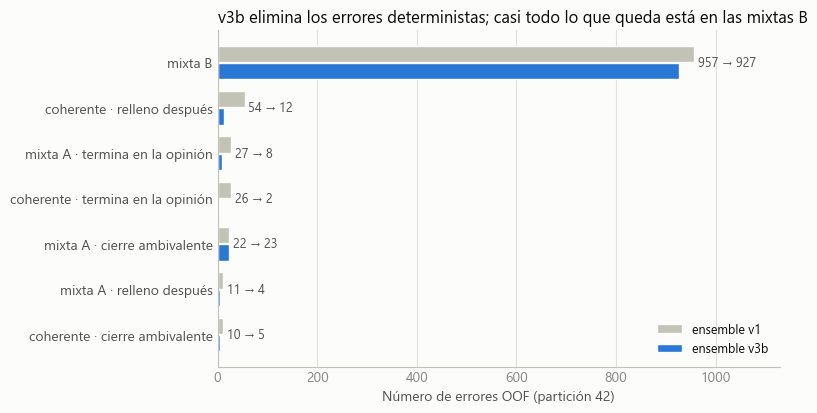

In [39]:
d = errores.drop('TOTAL')
d = d[(d.errores_v1 >= 10) | (d.errores_v3b >= 10)].sort_values('errores_v1')
fig, ax = plt.subplots(figsize=(8, 0.42 * len(d) + 1.3))
yy = np.arange(len(d))
ax.barh(yy + 0.19, d.errores_v1, height=0.36, color=GRIS, label='ensemble v1', edgecolor=SUPERFICIE, linewidth=1)
ax.barh(yy - 0.19, d.errores_v3b, height=0.36, color=AZUL, label='ensemble v3b', edgecolor=SUPERFICIE, linewidth=1)
for i, (a, b) in enumerate(zip(d.errores_v1, d.errores_v3b)):
    ax.text(max(a, b) + 8, i, f'{a} → {b}', va='center', fontsize=9, color=TINTA2)
ax.set_yticks(yy, d.index)
ax.set_xlim(0, d[['errores_v1', 'errores_v3b']].values.max() * 1.18)
ax.xaxis.grid(True); ax.set_axisbelow(True); ax.tick_params(length=0)
ax.set_xlabel('Número de errores OOF (partición 42)')
ax.set_title('v3b elimina los errores deterministas; casi todo lo que queda está en las mixtas B', color=TINTA)
ax.legend(loc='lower right', frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

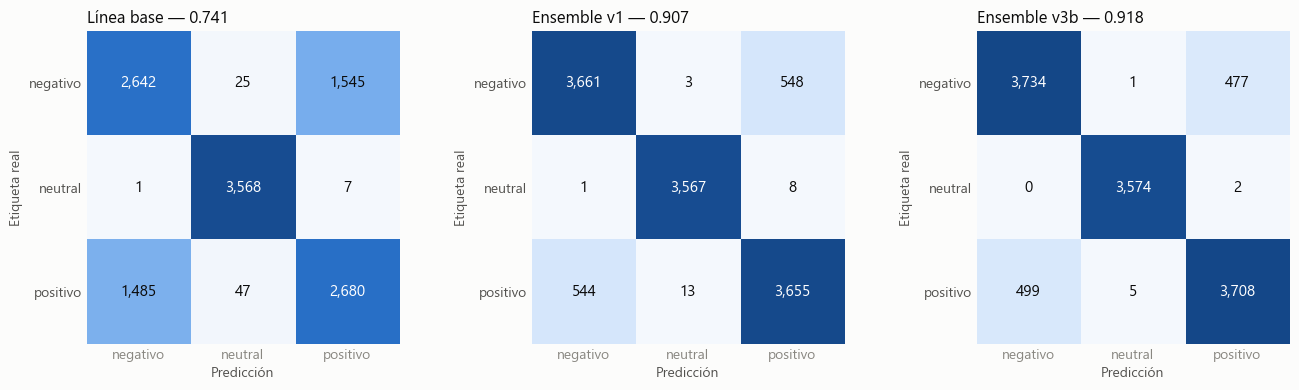

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))
graficar_confusion(axes[0], y, pred_base, f'Línea base — {accuracy_score(y, pred_base):.3f}')
graficar_confusion(axes[1], y, pred_v1, f'Ensemble v1 — {accuracy_score(y, pred_v1):.3f}')
graficar_confusion(axes[2], y, pred_v3b, f'Ensemble v3b — {accuracy_score(y, pred_v3b):.3f}')
plt.tight_layout(); plt.show()

La mejora viene sobre todo de celdas deterministas: reseñas coherentes seguidas de relleno (54 → 12 errores), coherentes que terminan en opinión (26 → 2), mixtas A que terminan en opinión (27 → 8) o con relleno (11 → 4) y neutrales (9 → 2). Las mixtas A con cierre ambivalente (22 → 23) se comportan como ruido, igual que las B. En las mixtas B v3b comete 30 errores menos que v1 (957 → 927), algo esperable si aprovecha las señales débiles de la sección 9, aunque esa cifra también está dentro del ruido. Después de v3b, el **94 %** de los errores restantes está en las mixtas B.

## 15. Iteraciones del modelo
Resumen de todo el recorrido con los números de esta ejecución (accuracy OOF de la partición 42; para los ensembles, también la selección anidada).

,accuracy_oof,seleccion_anidada,kaggle_publico
modelo,,,
0. Línea base: TF-IDF texto completo + LR,0.7408,,
1. Bloques + palabras + LR (lr_palabras),0.8951,,
2. Bloques + palabras y caracteres + LR,0.8981,,
3. Bloques + palabras y caracteres + SVM,0.8998,,
4. Stacking por bloques + HGB,0.9012,,
5. Ensemble v1 (4 componentes),0.9069,0.9067,0.90111
6. Componente estructural (solo),0.9075,,
7. Componente est_lr (solo),0.9126,,
8. v1 + estructural,0.9152,0.9152,


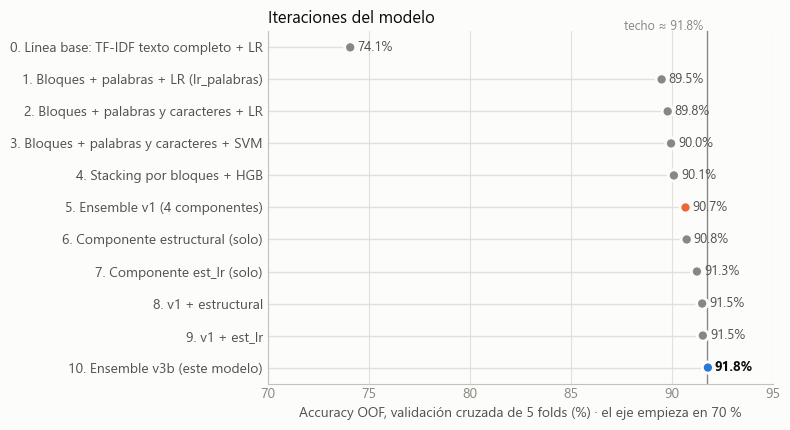

In [41]:
iteraciones = [
    ('0. Línea base: TF-IDF texto completo + LR', acc_oof(P_base), np.nan, ''),
    ('1. Bloques + palabras + LR (lr_palabras)', acc_oof(OOF['lr_palabras']), np.nan, ''),
    ('2. Bloques + palabras y caracteres + LR', acc_oof(OOF['lr_pal_car']), np.nan, ''),
    ('3. Bloques + palabras y caracteres + SVM', acc_oof(OOF['svc_pal_car']), np.nan, ''),
    ('4. Stacking por bloques + HGB', acc_oof(OOF['stacking']), np.nan, ''),
    ('5. Ensemble v1 (4 componentes)', oof_v1, anidado_v1.accuracy_parte_no_vista.mean(), '0.90111'),
    ('6. Componente estructural (solo)', acc_oof(OOF['estructural']), np.nan, ''),
    ('7. Componente est_lr (solo)', acc_oof(OOF['est_lr']), np.nan, ''),
    ('8. v1 + estructural', variantes_42.loc['v1 + estructural', 'accuracy_oof'],
     variantes_42.loc['v1 + estructural', 'seleccion_anidada'], ''),
    ('9. v1 + est_lr', variantes_42.loc['v1 + est_lr', 'accuracy_oof'], variantes_42.loc['v1 + est_lr', 'seleccion_anidada'], ''),
    ('10. Ensemble v3b (este modelo)', oof_v3b, anidado_v3b.accuracy_parte_no_vista.mean(), 'por enviar'),
]
tabla_iteraciones = pd.DataFrame(iteraciones, columns=['modelo', 'accuracy_oof', 'seleccion_anidada', 'kaggle_publico']).set_index('modelo')
display(tabla_iteraciones.style.format({'accuracy_oof': '{:.4f}', 'seleccion_anidada': '{:.4f}'}, na_rep=''))

fig, ax = plt.subplots(figsize=(8, 4.4))
ypos = np.arange(len(tabla_iteraciones))[::-1]
vals = tabla_iteraciones.accuracy_oof.values
colores = [AZUL if 'v3b' in m else (NARANJA if 'v1 (' in m else TENUE) for m in tabla_iteraciones.index]
ax.hlines(ypos, 0, 100 * vals, color=REJILLA, linewidth=1)
ax.scatter(100 * vals, ypos, s=64, color=colores, zorder=3, edgecolor=SUPERFICIE, linewidth=2)
for yy, v, m in zip(ypos, vals, tabla_iteraciones.index):
    ax.text(100 * v + 0.35, yy, f'{100 * v:.1f}%', va='center', fontsize=9.5,
            color=TINTA if 'v3b' in m else TINTA2, fontweight='bold' if 'v3b' in m else 'normal')
inicio = 5 * np.floor((100 * vals.min() - 2) / 5)
ax.axvline(100 * techo, color=TENUE, linewidth=1)
ax.text(100 * techo - 0.2, ypos[0] + 0.55, f'techo ≈ {100 * techo:.1f}%', color=TENUE, fontsize=9, ha='right')
ax.set_yticks(ypos, tabla_iteraciones.index)
ax.set_xlim(inicio, 95); ax.xaxis.grid(True); ax.set_axisbelow(True); ax.tick_params(length=0)
ax.set_xlabel(f'Accuracy OOF, validación cruzada de 5 folds (%) · el eje empieza en {inicio:.0f} %')
ax.set_title('Iteraciones del modelo', color=TINTA)
plt.tight_layout(); plt.show()

## 16. Experimentos que no funcionaron
Todos medidos con la misma validación cruzada (partición 42) y, para los ensembles, con la selección anidada de pesos. Se resumen para documentar el proceso; ninguno forma parte del modelo final.

| Experimento | Resultado | Conclusión |
|---|---|---|
| Otros clasificadores sobre los mismos bloques de palabras | LinearSVC 0.896 · LR 0.895 · Ridge 0.895 · SGD 0.888 · MultinomialNB 0.871 · ComplementNB 0.837 · kNN coseno 0.779 · ExtraTrees 0.783 (0.827 con χ² k=3000) · RandomForest 0.743 (0.777) · HGB denso χ² k=3000 0.888 · árbol de decisión 0.652 · LSA(300)+HGB 0.767 · LSA+LR 0.776 | Los lineales dominan sobre TF-IDF disperso; los árboles necesitan pocos rasgos densos (por eso funcionan como meta-modelo o sobre rasgos estructurales) |
| Variantes de preprocesamiento (sonda: LR sobre bloques = 0.8951) | mantener tildes 0.8877 · corregir typos 0.8953 · stemming 0.8950 · typos + stemming 0.8956 · quitar stopwords 0.8911 · marcar negación 0.8928 · números → token 0.8952 · TF-IDF binario 0.8937 · sin IDF 0.8878 · sin `sublinear_tf` 0.8947 · `min_df` 1 / 5: 0.8948 / 0.8938 · `max_df` 0.5: 0.8942 · norma L1 0.868 | Diferencias ≤ 0.05 pts o peores: los n-gramas de caracteres ya cubren typos y morfología |
| Quitar del train las reseñas con etiqueta sospechosa (*confident learning*, umbrales 0.15 / 0.3 / 0.45) | 0.891 / 0.890 / 0.885 | Empeora: el ruido (mixtas B) también está en `eval` y no se puede "limpiar" |
| Búsqueda aleatoria de hiperparámetros de los 3 lineales (87 configuraciones) | ±0.1 pts | Los valores elegidos ya eran óptimos |
| Meta-HGB del stacking ajustado (lr 0.03, 150 iteraciones, `max_features` 0.7) | stacking 0.898 → 0.9025, pero ensemble anidado 0.9038–0.9052 (v1: 0.9064) | Mejorar un miembro no mejora la mezcla |
| v2: stacking + ~15 rasgos estructurales del detector de cláusulas antiguo | ensemble 0.9067 OOF / 0.9052 anidado | Rasgos demasiado ruidosos; la versión buena es `est_lr` |
| Meta-modelo de 2.º nivel (LR / HGB) sobre las OOF + conector + tipo de cierre | 0.900–0.906 | No supera al voto ponderado |
| HGB de árboles (χ² k=3000) como miembro extra del ensemble | peso óptimo 0 (anidado 0.9037) | No aporta información nueva |
| kNN / paráfrasis | similitud coseno mediana con el vecino más cercano 0.27; 1-NN acierta 50 % en las mixtas difíciles | No hay reseñas casi duplicadas que aprovechar |
| Rasgos aspecto × polaridad en mixtas aditivas | ~53 % | Azar (luego explicado: son mixtas B) |
| Autoentrenamiento del clasificador de cláusulas desde la etiqueta del documento | colapsó: regla "conector fuerte → última opinión" 0.694 frente a 0.861 del detector antiguo | La etiqueta del documento solo coincide ~72 % con la de la cláusula |
| Una ronda de autoentrenamiento sobre el clasificador de fragmentos de `est_lr` | sin cambio (fold 0: 0.9021 → 0.9021) | La supervisión débil ya cubre casi todo |
| `est_lr` con HGB en lugar de LR como meta-modelo | componente 0.9093 (LR: 0.9127); ensemble +0.43 pts (LR: +0.52) | Sobreajusta el grupo aleatorio |
| Hipótesis para predecir las mixtas B: orden, posición, aspecto, intensidad, identidad del cierre, mayoría, TF-IDF dentro del subconjunto (LR, árbol, HGB; 100 permutaciones) | 0.47–0.53; permutaciones p = 0.22–0.96; "gana la última" 49.9 % en las que terminan en relleno o cierre | Ruido de etiqueta: no hay señal que aprender |
| NB-LR (Wang & Manning) como componente plano | 0.9000 solo (el mejor lineal), pero ensemble anidado −0.20 pts | Muy correlacionado con los lineales existentes |
| Tokens conjuntados con el conector o la posición · pares de palabras entre cláusulas (hashing) · rangos de n-gramas por bloque | ensemble anidado −0.08 a −0.27 · −0.27 · −0.07 pts | Sobreajustan |
| Stacking NB-LR con bloques anclados en opiniones (`stk_nb6_anc`) | componente 0.9113; ensemble +0.86 pts con la partición 42 pero solo +0.30 con la 2024 | Mejora inestable entre particiones por sí solo; no se incluye en v3b (es el componente alternativo del modelo A, v3a, que se documenta en otro notebook) |

## 17. Modelo final: entrenamiento con todo `train`, guardado y recarga
El modelo final es un `VotingClassifier(voting='soft')` con los pesos elegidos en la sección 12. Incluye solo los componentes con peso mayor que cero y se entrena con las 12 000 reseñas de `train`. Todo el preprocesamiento (normalización, bloques, parser, corrector, segmentación, TF-IDF) está dentro de los estimadores, así que el objeto guardado recibe **texto crudo**. `est_lr` usa `semilla_interna = 1000` para su cross-fitting interno. `eval.csv` no se usa en ningún momento del entrenamiento.

In [42]:
FABRICAS = {**FABRICAS_V1, 'estructural': modelo_estructural, 'est_lr': modelo_est_lr}
PESOS = {n: w for n, w in pesos_v3b.items() if w > 0}
miembros = [(n, FABRICAS[n]()) for n in PESOS]
modelo_final = VotingClassifier(miembros, voting='soft', weights=list(PESOS.values()), n_jobs=N_JOBS)

t0 = time.time()
modelo_final.fit(X, y)
segundos_ajuste = time.time() - t0
print(f'Entrenado en {segundos_ajuste:.0f} s con miembros {list(PESOS)} y pesos {list(PESOS.values())}')

joblib.dump(modelo_final, 'modelo_v3b.joblib', compress=3)
tamano_mb = os.path.getsize('modelo_v3b.joblib') / 2**20
print(f'Modelo guardado en modelo_v3b.joblib ({tamano_mb:.1f} MB)')

Entrenado en 184 s con miembros ['stacking', 'lr_palabras', 'estructural', 'est_lr'] y pesos [0.2, 0.3, 0.3, 0.2]


Modelo guardado en modelo_v3b.joblib (9.4 MB)


In [43]:
pred_eval = modelo_final.predict(evaluacion.text.values)
proba_eval = modelo_final.predict_proba(evaluacion.text.values)

modelo_cargado = joblib.load('modelo_v3b.joblib')
pred_recarga = modelo_cargado.predict(evaluacion.text.values)
assert (pred_recarga == pred_eval).all()
assert np.allclose(modelo_cargado.predict_proba(evaluacion.text.values), proba_eval)
print('El modelo recargado reproduce exactamente las predicciones (y probabilidades) de eval.csv')
modelo_cargado.predict(['La batería es excelente, pero la cámara resultó decepcionante.',
                        'La cámara resultó decepcionante. Aun así, la batería es excelente.',
                        'Me llegó en tres días. Trae garantía de un año y usa dos pilas AA.'])

El modelo recargado reproduce exactamente las predicciones (y probabilidades) de eval.csv


array(['negativo', 'positivo', 'neutral'], dtype=object)

Para cargar `modelo_v3b.joblib` en otra sesión hay que ejecutar antes las celdas que definen las funciones, clases y tablas globales que el modelo referencia (`normalizar`, `oraciones`, `Bloques` y sus regex; el inventario, el parser y `RasgosPlantilla`; la segmentación con sus tablas de conectores como `FR_TIPO`, el léxico, `ClasificadorFragmentos` y `ComponenteEstLR`), porque `joblib` guarda referencias a ellas, no su código. Hay que ejecutarlas **enteras**: si falta una entrada de una tabla global, `est_lr` no da error, sino que cambia sus predicciones sin avisar. Lo más seguro es ejecutar el notebook hasta la sección 11 (con `VERIFICAR_2024 = False`). Lo comprobamos aparte en un proceso nuevo: con esas definiciones, el modelo recargado reproduce exactamente `submission_v3b.csv`.

**Cómo ve el modelo una reseña.** Para la sustentación es útil abrir la caja: probabilidades de cada componente y clase de cada fragmento según el clasificador de fragmentos del modelo final.

In [44]:
def explicar(texto):
    print(texto, '\n')
    probas = {n: est.predict_proba([texto])[0] for n, est in zip(PESOS, modelo_final.estimators_)}
    probas['ENSEMBLE v3b'] = modelo_final.predict_proba([texto])[0]
    display(pd.DataFrame(probas, index=CLASES).T.round(3))
    if 'est_lr' in PESOS:
        est_lr_final = modelo_final.estimators_[list(PESOS).index('est_lr')]
        segs = segmentar(normalizar(texto))
        Pf = est_lr_final.fragmentos_.predecir_fragmentos([d['texto'] for d in segs])
        for d, p in zip(segs, Pf):
            print(f"  {CLASES_FRAGMENTO[p.argmax()]:>6s} ({p.max():.2f})  [{d['tipo_con']}] {d['texto']}")

explicar(X[ejemplos[0]])

Comparto mi experiencia con este aparato que lo compre a mediados de mes y llego en tres dias a mi casa. La verdad sea dicha, el boton de encendido me parecio incomodo en el uso real, lo he estado usando en la oficina todas las tardes. Aun asi, tuve que escribirles un par de veces por una duda de configuracion y el soporte tecnico se sintio funcional al final de cuentas. 



,negativo,neutral,positivo
stacking,0.001,0.000,0.999
lr_palabras,0.059,0.000,0.941
estructural,0.000,0.000,1.000
est_lr,0.041,0.001,0.959
ENSEMBLE v3b,0.026,0.000,0.974


  sin_op (1.00)  [ninguno] comparto mi experiencia con este aparato que lo compre a mediados de mes y llego en tres dias a mi casa.
      A- (0.98)  [ninguno] la verdad sea dicha el boton de encendido me parecio incomodo en el uso real
  sin_op (1.00)  [ninguno] lo he estado usando en la oficina todas las tardes.
  sin_op (0.95)  [fuerte] aun asi tuve que escribirles un par de veces por una duda de configuracion
      A+ (0.99)  [y] y el soporte tecnico se sintio funcional al final de cuentas.


## 18. Submission
Archivo `submission_v3b.csv` con el formato `id,answer` de `sample_submission.csv`. Validamos columnas, número de filas, ids (mismo orden) y valores, y comparamos con el envío actual `submission.csv` (ensemble v1, **0.90111** en la tabla pública).

In [45]:
submission = pd.DataFrame({'id': evaluacion.id, 'answer': pred_eval})
assert list(submission.columns) == list(muestra.columns) == ['id', 'answer']
assert len(submission) == len(muestra) == 3000
assert (submission.id.values == muestra.id.values).all() and submission.id.is_unique
assert submission.answer.isin(CLASES).all() and submission.answer.notna().all()
submission.to_csv('submission_v3b.csv', index=False)
print('submission_v3b.csv generado:', submission.shape)

distribucion = pd.DataFrame({'eval (predicho v3b)': submission.answer.value_counts(normalize=True),
                             'train (real)': train.label.value_counts(normalize=True)}).round(3)
display(distribucion)

actual = pd.read_csv('submission.csv')
assert (actual.id.values == submission.id.values).all()
cambios = actual.answer.values != submission.answer.values
print(f'Predicciones que cambian respecto a submission.csv (v1): {cambios.sum()} de {len(submission)} '
      f'({100 * cambios.mean():.1f} %)')
display(pd.crosstab(pd.Series(actual.answer.values, name='submission.csv (v1)'),
                    pd.Series(submission.answer.values, name='submission_v3b.csv')))
submission.head()

submission_v3b.csv generado: (3000, 2)


,eval (predicho v3b),train (real)
negativo,0.368,0.351
neutral,0.276,0.298
positivo,0.356,0.351


Predicciones que cambian respecto a submission.csv (v1): 136 de 3000 (4.5 %)


submission_v3b.csv,negativo,neutral,positivo
submission.csv (v1),,,
negativo,1032,1,54
neutral,2,822,3
positivo,70,6,1010


,id,answer
0,0,neutral
1,1,positivo
2,2,neutral
3,3,neutral
4,4,neutral


Cambian 136 de las 3 000 predicciones (4.5 %), casi todas entre `positivo` y `negativo` (124 de 136): es lo esperado, porque v3b cambia sobre todo la decisión en reseñas mixtas. En las OOF de train, v3b y v1 discrepan en acierto en 385 reseñas de 12 000 (3.2 %), del mismo orden. La distribución de clases predicha es parecida a la de train, con algo menos de neutrales (27.6 % frente a 29.8 %).

**Ojo con la tabla pública de Kaggle:** solo usa el 30 % de `eval` (900 reseñas), con un error estándar de ≈ ±1 punto de accuracy, mayor que la mejora esperada (≈ +1 punto). Un resultado público algo mejor o peor que 0.90111 no confirma ni refuta el modelo; la validación cruzada con dos particiones es la estimación más fiable. Aun así, por el sesgo de diseño y la cobertura del parser (secciones 13.2 y 20), lo esperable en `eval` es una mejora algo menor que la del CV.

## 19. Cumplimiento de las reglas del proyecto
La celda siguiente recorre el modelo final ya entrenado, lista **todas** las clases que contiene y comprueba que solo hay estimadores y transformadores de scikit-learn o código propio de este notebook (reglas, regex, léxicos), y que no se cargó ninguna librería prohibida.

In [46]:
def clases_del_modelo(objeto):
    vistos, tipos = set(), set()
    def recorrer(o):
        if id(o) in vistos or isinstance(o, (str, bytes, int, float, bool, type(None), np.ndarray, np.generic)):
            return
        vistos.add(id(o))
        modulo = type(o).__module__
        if modulo.startswith('sklearn') or modulo == '__main__':
            tipos.add(f'{modulo}.{type(o).__name__}')
            for v in getattr(o, '__dict__', {}).values():     # objetos compilados (Cython) no tienen __dict__
                recorrer(v)
        elif isinstance(o, (list, tuple, set)):
            for v in o:
                recorrer(v)
        elif isinstance(o, dict):
            for v in list(o.values())[:1000]:       # los vocabularios (palabra -> índice) no contienen objetos
                recorrer(v)
    recorrer(objeto)
    return sorted(tipos)

tipos = clases_del_modelo(modelo_cargado)
print('Clases presentes en el modelo final:')
for t in tipos:
    print('  ', t)

PROHIBIDAS = ['torch', 'tensorflow', 'keras', 'transformers', 'sentence_transformers', 'gensim', 'fasttext', 'spacy',
              'stanza', 'flair', 'xgboost', 'lightgbm', 'catboost', 'sklearn.neural_network']
assert all(t.startswith('sklearn.') or t.startswith('__main__.') for t in tipos)
assert not any('MLP' in t or 'neural' in t.lower() for t in tipos)
cargadas = [m for m in PROHIBIDAS if m in sys.modules]
assert not cargadas, cargadas
print('\nNinguna librería prohibida está cargada:', ', '.join(PROHIBIDAS))

Clases presentes en el modelo final:


   __main__.Bloques
   __main__.ClasificadorFragmentos
   __main__.ComponenteEstLR
   __main__.CorrectorTypos
   __main__.RasgosPlantilla
   __main__.VectorizadorFragmentos
   sklearn._loss.link.Interval
   sklearn._loss.link.MultinomialLogit
   sklearn._loss.loss.HalfMultinomialLoss
   sklearn.compose._column_transformer.ColumnTransformer
   sklearn.ensemble._hist_gradient_boosting.binning._BinMapper
   sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier
   sklearn.ensemble._hist_gradient_boosting.predictor.TreePredictor
   sklearn.ensemble._stacking.StackingClassifier
   sklearn.ensemble._voting.VotingClassifier
   sklearn.feature_extraction.text.TfidfTransformer
   sklearn.feature_extraction.text.TfidfVectorizer
   sklearn.linear_model._logistic.LogisticRegression
   sklearn.model_selection._split.StratifiedKFold
   sklearn.pipeline.Pipeline
   sklearn.preprocessing._data.StandardScaler
   sklearn.preprocessing._label.LabelEncoder
   sklearn.ut

**Lista de verificación**
- ✅ **Solo ML clásico de scikit-learn:** `TfidfVectorizer` (bolsa de palabras y n-gramas de palabras y caracteres), `LogisticRegression`, `LinearSVC` + `CalibratedClassifierCV`, `HistGradientBoostingClassifier`, `StackingClassifier`, `VotingClassifier`, `StandardScaler`, `ColumnTransformer`, `Pipeline`. El resto es ingeniería de rasgos propia: regex, reglas, léxicos escritos a mano y un corrector de typos por distancia de edición.
- ✅ **Sin redes neuronales** (tampoco `MLPClassifier`), deep learning, transformers, embeddings preentrenados, modelos de lenguaje ni xgboost / lightgbm / catboost (comprobado arriba).
- ✅ **`eval.csv` no se usa para entrenar ni ajustar nada:** se lee en la sección 2 solo para comprobar su formato y en las secciones 17-18 solo para predecir. Vocabularios, IDF, léxicos aprendidos (polaridad de claves, polaridad de adjetivos), corrector de typos y todos los modelos se ajustan solo con `train` (y, en la validación cruzada, solo con el fold de entrenamiento).
- ✅ **Validación sin fuga:** todas las OOF salen de `cross_val_predict` o de `oof_por_fold` (equivalente); `est_lr` hace su cross-fitting dentro de `fit`; los pesos del ensemble se validan con selección anidada y con una segunda partición.
- ⚠️ **Sesgo de diseño declarado:** el inventario del parser y el léxico de frases se escribieron a mano mirando reseñas de train (sección 20).

## 20. Conclusiones y limitaciones

**Conclusiones**
- **De 0.741 a 0.9180 de accuracy OOF sin salir del ML clásico.** Las mejoras no vinieron de cambiar de clasificador, sino de **entender cómo se generaron los datos** y llevar esa estructura a la representación: primero el orden respecto a los conectores (bloques, v1) y después la familia de plantilla de cada opinión (v3b).
- **v3b mejora a v1 de forma consistente:** +1.02 pts de accuracy con selección anidada en la partición 42 y +1.02 en la 2024 (semilla 123), y +1.03 pts de media (entre +0.89 y +1.18) sobre 2 particiones × 3 semillas de selección, con McNemar anidado significativo en todas (sección 13.1). Esa cifra es una **cota optimista** para reseñas nuevas (ver limitaciones): con el parser algo degradado (prueba de estrés leve, sección 13.2) baja a +0.86 pts, y descontando el sesgo de diseño y el ruido numérico una estimación prudente es de +0.6 a +0.9 pts.
- **Los dos componentes nuevos se solapan.** El parser determinista (`estructural`) es muy preciso cuando reconoce la plantilla y es el que más mejora el ensemble por sí solo (*v1 + estructural*: +1.00 pts de media). El clasificador de fragmentos (`est_lr`) es el mejor componente individual (0.9126) y mejora a v1 en +0.55 pts de media (entre +0.47 y +0.65). Pero **el aporte marginal medido de `est_lr` dentro de v3b es prácticamente nulo** (+0.03 pts de media: suma un poco con la partición 42, con la que se diseñó, y resta un poco con la 2024): en validación cruzada, *v1 + estructural* rinde lo mismo con un componente menos. Lo que justifica mantenerlo es la robustez frente a los fallos del parser: en la prueba de estrés leve v3b conserva +0.86 pts de mejora, frente a +0.68 de *v1 + estructural*, y pierde menos en todas las combinaciones (sección 13.2).
- **Lo que queda es casi todo ruido:** tras v3b, el 94 % de los errores están en las mixtas B.

**Limitaciones**
- **Ruido irreducible de la plantilla B.** El 17.0 % del train son reseñas mixtas con frases hechas cuya etiqueta es ~50/50. Ningún método que solo vea el texto puede acertarlas, así que el techo práctico en validación cruzada ronda **0.915–0.92**, y v3b (0.9169 anidado) ya está en ese nivel. Mejoras futuras de menos de ~0.3 pts serán sobre todo ruido de ese grupo (o ruido numérico, sección 8).
- **Sesgo de diseño.** El inventario del parser (cópulas, adjetivos, frases hechas, conectores, cierres) y el léxico del clasificador de fragmentos se escribieron **a mano mirando reseñas de train**, incluidas tasas por etiqueta. La versión 2 del inventario (9 claves nuevas, unas 40 alternativas, 12 verbos copulativos y la regla de negación *no + adjetivo*) se amplió leyendo errores OOF de la partición 42, y 35 de los 59 rasgos del componente estructural (las interacciones) se diseñaron mirando tablas por celda con etiquetas y con las OOF de v1. Todo lo que se ajusta a datos se entrena dentro de cada fold, pero esas decisiones de diseño no están anidadas en el CV, así que la estimación es optimista. Unos análisis de sensibilidad hechos aparte acotan el efecto. Usaron las OOF de los experimentos y 2 particiones × 3 semillas de selección; no se repiten en este notebook y, como su stacking difiere en los decimales por los hilos, sus cifras no coinciden exactamente con las de la sección 13.1:
  - la ganancia de *v1 + estructural* fue de +0.84 pts de media con el inventario completo, +0.78 sin ninguna entrada añadida a partir de errores, de +0.59 a +0.70 descartando las entradas o frases con poco soporte (menos de 5 o 10 reseñas) en el train de cada fold y +0.65 sin las 35 interacciones; el mínimo sobre todas las variantes y combinaciones fue +0.42;
  - en `est_lr`, quitar las 47 entradas del léxico que pudieron añadirse tras mirar errores apenas cambió su aporte (optimismo estimado < 0.1 pts);
  - en conjunto, el sesgo infla la ganancia en unas 0.1-0.25 pts, pero no la explica. Junto con el ruido numérico (punto siguiente), una estimación prudente de la mejora de v3b sobre v1 en reseñas nuevas es de +0.6 a +0.9 pts.
- **Cobertura del inventario.** Si una reseña usa giros que el inventario no contiene (un verbo copulativo o un intensificador nuevo), el parser pierde la opinión y el componente estructural se equivoca con confianza. En la prueba de estrés (sección 13.2, solo con train) la ganancia de v3b baja de +1.03 a +0.86 pts (nivel leve) y +0.73 (severo), y la de *v1 + estructural* llega a +0.43 con el severo. Por eso, en `eval` cabe esperar algo menos de mejora que en el CV. El inventario queda congelado tal como se validó: no se amplía con más errores ni con datos de evaluación.
- **Selección con la partición 42.** Los pesos, el meta-modelo de `est_lr` y casi todas las decisiones de diseño se eligieron mirando esa partición, y la variante final del componente estructural, mirando también la 2024: la 2024 es una verificación, no una prueba totalmente independiente. El reparto exacto de pesos tampoco es estable (partición 42: stacking 0.2 · lr_palabras 0.3 · estructural 0.3 · est_lr 0.2; partición 2024: lr_palabras 0.3 · lr_pal_car 0.1 · estructural 0.4 · est_lr 0.2); lo estable es que los componentes nuevos reciben la mitad o más del peso.
- **Reproducibilidad numérica.** El notebook fija 4 hilos y se reproduce exactamente en esta máquina, pero con otra CPU o librería BLAS los decimales pueden cambiar: la OOF del stacking varió entre 0.8973 y 0.9012 según los hilos (sección 8), y eso basta para mover la ganancia media de v3b de la sección 13.1: con las OOF de los experimentos, calculadas con otros hilos, la misma tabla da +0.81 pts en lugar de +1.03. Diferencias de menos de ~0.3 pts entre ensembles no son concluyentes.
- **Kaggle.** La tabla pública usa 900 reseñas (error estándar ≈ ±1 pt): no sirve para distinguir mejoras de menos de un punto.
- **Generalización.** El parser está hecho a la medida del generador de este corpus. Con reseñas reales (otras plantillas, ironía, opiniones sin marcadores) perdería buena parte de su ventaja: el orden y la estructura se inyectan "a mano" con reglas, una limitación de la bolsa de palabras que motiva los modelos secuenciales de la Parte 2.

In [47]:
# Resumen numérico de esta ejecución (los textos del notebook citan estos valores)
def pts(a, b):
    return round(100 * (a - b), 2)

an_v1, an_v3b = anidado_v1.accuracy_parte_no_vista.mean(), anidado_v3b.accuracy_parte_no_vista.mean()
mc42 = mcnemar(pred_v3b, pred_v1, y)
fam_A_op = F[(F.familia == FAM_A) & (F.final == 'opinion')]
RESUMEN = {
    'n_train': len(y), 'acc_linea_base': round(acc_oof(P_base), 4),
    'acc_componentes_v1': {n: round(acc_oof(OOF[n]), 4) for n in NOMBRES_V1},
    'acc_estructural': round(acc_oof(OOF['estructural']), 4), 'acc_est_lr': round(acc_oof(OOF['est_lr']), 4),
    'oof_v1': round(oof_v1, 4), 'anidado_v1': round(an_v1, 4), 'pesos_v1': pesos_v1,
    'oof_v1_enviado': round(oof_v1_enviado, 4),
    'oof_v3b': round(oof_v3b, 4), 'anidado_v3b': round(an_v3b, 4), 'pesos_v3b': pesos_v3b,
    'delta_42': pts(an_v3b, an_v1), 'mcnemar_42': mc42,
    'variantes_42': variantes_42.drop(columns='pesos').to_dict('index'),
    'n_A_op': len(fam_A_op), 'pct_A_ultima_op': round(100 * fam_A_op.gana_ultima.mean(), 1),
    'n_B': len(B_mix), 'pct_B_train': round(100 * len(B_mix) / len(y), 1),
    'pct_B_ultima': round(100 * B_mix.gana_ultima.mean(), 1),
    'pct_B_ultima_op': round(100 * B_mix[B_mix.final == 'opinion'].gana_ultima.mean(), 1),
    'acc_v1_B': round(100 * B_mix.acierto_v1.mean(), 1), 'errores_min_B': int(round(errores_min_B)),
    'techo': round(techo, 3),
    'errores_v1': int((~F.acierto_v1).sum()), 'errores_v3b': int((~F.acierto_v3b).sum()),
    'errores_v1_fuera_B': int((~F.acierto_v1 & (F.familia != FAM_B)).sum()),
    'pct_errores_B': round(100 * n_err_B / (~F.acierto_v3b).sum()),
    'miembros_finales': list(PESOS), 'tamano_mb': round(tamano_mb, 1), 'segundos_ajuste': round(segundos_ajuste),
    'n_cambios': int(cambios.sum()), 'pct_cambios': round(100 * cambios.mean(), 1),
    'distribucion_eval': submission.answer.value_counts().to_dict(),
    'discrepan_oof': int(((pred_v3b == y) != (pred_v1 == y)).sum()),
    'segundos_componentes': {n: round(s) for n, s in SEGUNDOS.items()},
}
if VERIFICAR_2024:
    an1 = variantes_2024.loc['v1 (4 componentes)', 'seleccion_anidada']
    an3 = variantes_2024.loc['v3b = v1 + estructural + est_lr', 'seleccion_anidada']
    RESUMEN.update({
        'acc_componentes_2024': {n: round(acc_oof(OOF_2024[n]), 4) for n in NOMBRES_V3B},
        'anidado_v1_2024': round(an1, 4), 'anidado_v3b_2024': round(an3, 4), 'delta_2024': pts(an3, an1),
        'variantes_2024': variantes_2024.to_dict('index'),
        'acc_pesos42_en_2024': round(acc_pesos42_en_2024, 4), 'acc_v1_enviado_2024': round(acc_v1_enviado_2024, 4),
    })
RESUMEN['robustez'] = {k: {c: round(float(v), 2) for c, v in fila.items()} for k, fila in resumen_robustez.iterrows()}
RESUMEN['robustez_filas'] = {f'{p}/{s}': {c: round(float(v), 2) for c, v in fila.items()} for (p, s), fila in robustez.iterrows()}
RESUMEN['mcnemar_anidado'] = {f"{r['partición']}/{r['semilla anidada']} {r['comparación']}": [r['gana'], r['pierde'], float(r['p'])]
                              for _, r in mcnemar_anidado.iterrows()}
RESUMEN['estres'] = {k: {c: round(float(v), 2) for c, v in fila.items()} for k, fila in resumen_estres.iterrows()}
RESUMEN['acc_perturbadas_leve_42'] = {k: [round(a, 3), round(b, 3)] for k, (a, b) in acc_perturbadas.items()}
RESUMEN['n_perturbadas_leve_42'] = int(mascara_leve.sum())
RESUMEN['polaridad_folds'] = [int(polaridad_folds['distintas de la semántica'].sum()),
                              int(polaridad_folds['claves con polaridad aprendida'].sum()), len(polaridad_folds)]
RESUMEN['minutos_ejecucion'] = round((time.time() - T_INICIO) / 60, 1)
import json
print(json.dumps(RESUMEN, ensure_ascii=False, indent=1, default=float))

{
 "n_train": 12000,
 "acc_linea_base": 0.7408,
 "acc_componentes_v1": {
  "stacking": 0.9012,
  "lr_palabras": 0.8951,
  "lr_pal_car": 0.8981,
  "svc_pal_car": 0.8998
 },
 "acc_estructural": 0.9075,
 "acc_est_lr": 0.9126,
 "oof_v1": 0.9069,
 "anidado_v1": 0.9067,
 "pesos_v1": {
  "stacking": 0.5,
  "lr_palabras": 0.4,
  "lr_pal_car": 0.0,
  "svc_pal_car": 0.1
 },
 "oof_v1_enviado": 0.9054,
 "oof_v3b": 0.918,
 "anidado_v3b": 0.9169,
 "pesos_v3b": {
  "stacking": 0.2,
  "lr_palabras": 0.3,
  "lr_pal_car": 0.0,
  "svc_pal_car": 0.0,
  "estructural": 0.3,
  "est_lr": 0.2
 },
 "delta_42": 1.02,
 "mcnemar_42": {
  "gana": 259,
  "pierde": 126,
  "p": 1.0854133854675097e-11
 },
 "variantes_42": {
  "v1 (4 componentes)": {
   "accuracy_oof": 0.9069166666666667,
   "seleccion_anidada": 0.9066666666666668,
   "mcnemar_gana": 0,
   "mcnemar_pierde": 0,
   "p_valor": 1.0
  },
  "v1 + estructural": {
   "accuracy_oof": 0.9151666666666667,
   "seleccion_anidada": 0.9151666666666667,
   "mcnemar_gan